[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hams-chadi/hams-assessment/blob/main/notebooks/arabic_english_speech_translation.ipynb)

# Real-Time Arabic-to-English Speech Translation

## SeamlessM4T-v2 with LoRA Fine-Tuning

---

### Objective

Build and fine-tune a real-time Arabic-to-English speech translation system for a
customer-support use case: a human agent speaks Arabic and the customer hears English.
The system is optimized for low latency, good translation quality, small deployment
size, and open-source-only components.

### Selected Track

**Modern Standard Arabic (MSA) -> English.**
The dataset, fine-tuning, evaluation, and demo are all aligned to this track.

### Architecture Decision

This notebook implements the **acceptable fallback architecture** from the assessment:

    Arabic speech -> English text (direct speech translation, fine-tuned)
                  -> English speech (local open-source TTS)

This qualifies as an accepted approach because:

1. The Arabic speech is translated **directly** into English text by SeamlessM4T-v2.
   It is a direct speech-to-text-translation (S2TT) model, not a chained
   `ASR -> MT` pipeline. There is no separate Arabic transcription step.
2. The speech translation model is **fine-tuned** (LoRA), and it is the main component.
3. **No LLM** is used as the translation engine.
4. The TTS model is **open-source and runs locally** (no cloud APIs).
5. The final system outputs **English speech**.

SeamlessM4T-v2 also natively supports direct speech-to-speech (S2ST). We focus the
fine-tuning effort on the S2TT path because the translation quality bottleneck lives
in the encoder and text decoder; the text-to-unit (T2U) module and vocoder that turn
English text into English speech do not need Arabic-specific adaptation.

### Why Not a Cascaded Pipeline

The forbidden architecture is `Arabic STT -> LLM/MT translation -> English TTS`.
We avoid it: SeamlessM4T performs the speech-to-translation step end-to-end in a
single model, and no LLM or external MT engine is involved.

### Base Model and Licensing

| Component        | Name                                  | License        | Commercial Use |
|------------------|---------------------------------------|----------------|----------------|
| Translation      | facebook/seamless-m4t-v2-large        | CC BY-NC 4.0   | Non-commercial |
| Dataset          | CoVoST-2 (AR->EN)                     | CC0            | Yes            |
| TTS              | Local neural TTS (Kokoro / pyttsx3)   | Apache 2.0     | Yes            |
| PEFT (LoRA)      | huggingface/peft                      | Apache 2.0     | Yes            |

The SeamlessM4T base model is CC BY-NC 4.0, which restricts commercial deployment.
For a commercial product, the base model would need to be replaced with a permissively
licensed alternative (for example Whisper under MIT for the speech encoder, paired with
a permissively licensed translation decoder). This is documented in the model card.

### Hardware Target

The assessment caps the final benchmark at an **NVIDIA L4 (24 GB VRAM)**. All training
and inference settings in this notebook are chosen to fit within 24 GB. LoRA keeps the
trainable parameter count below half a percent of the model, so fine-tuning fits
comfortably on an L4.

### Table of Contents

1. Environment Setup and Configuration
2. Dataset Loading and Exploration
3. Preprocessing and Data Collator
4. Zero-Shot Baseline (before fine-tuning)
5. LoRA Fine-Tuning (corrected training loop)
6. Reload and Merge the Adapter for Inference
7. Before vs After Evaluation (BLEU, chrF, COMET, human eval, error analysis)
8. Local Text-to-Speech
9. Full Pipeline: Arabic Speech to English Speech
10. Latency Benchmarking
11. Concurrency Benchmarking
12. Optimization Notes
13. Model Card and Documentation

---
## 1. Environment Setup and Configuration

This section installs dependencies, imports libraries, sets a fixed random seed for
reproducibility, detects the available device, and defines the global configuration
(model identifiers, language codes, sample rate, and output paths).

All randomness is seeded so that data splits and training are reproducible.


In [1]:
# ------------------------------------------------------------
# 1.1 Install dependencies (uncomment on first run)
# ------------------------------------------------------------
# Core ML / HuggingFace stack
# !pip install -q "transformers>=4.40.0" "datasets>=2.18.0" "accelerate>=0.28.0"
# Parameter-efficient fine-tuning
# !pip install -q "peft>=0.10.0"
# Audio
# !pip install -q torchaudio soundfile librosa
# Metrics
# !pip install -q sacrebleu evaluate unbabel-comet
# Local TTS (choose one; Kokoro is higher quality, pyttsx3 has zero heavy deps)
# !pip install -q kokoro>=0.9.4 "misaki[en]"
# !pip install -q pyttsx3
# Utilities
# !pip install -q sentencepiece protobuf tqdm matplotlib pandas
print("If this is the first run, uncomment the installs above and run once.")


If this is the first run, uncomment the installs above and run once.


In [2]:
# ------------------------------------------------------------
# 1.2 Imports
# ------------------------------------------------------------
import os
import gc
import json
import time
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torchaudio
import soundfile as sf

from datasets import load_dataset, Audio
from transformers import (
    AutoProcessor,
    SeamlessM4Tv2ForSpeechToText,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

from sacrebleu.metrics import BLEU, CHRF

warnings.filterwarnings("ignore")
print("Imports complete.")


c:\Users\PC\Desktop\Aymane\hams\hams_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports complete.


In [3]:
# ------------------------------------------------------------
# 1.3 Configuration and reproducibility
# ------------------------------------------------------------
SEED = 42
set_seed(SEED)

# Device detection. The assessment target is an NVIDIA L4 (24 GB).
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print("  Note: the assessment requires the FINAL benchmark to run on an NVIDIA L4 (24 GB).")
    print("        Training and inference settings below are sized to fit within 24 GB.")

# Model identifier. SeamlessM4T-v2 large is the only v2 checkpoint published by Meta;
# there is no separate 'medium' v2 checkpoint, so we use 'large' and rely on LoRA to
# keep the trainable footprint small.
BASE_MODEL = "facebook/seamless-m4t-v2-large"

# Language codes used by SeamlessM4T (ISO 639-3).
SRC_LANG = "arb"   # Modern Standard Arabic
TGT_LANG = "eng"   # English

SAMPLE_RATE  = 16_000   # SeamlessM4T expects 16 kHz audio
MAX_LABEL_LEN = 128     # max target token length

# Subset sizes. Keep modest so a full run finishes in a few hours on an L4.
# Increase for a production run.
TRAIN_SUBSET = 2000
VALID_SUBSET = 300
TEST_SUBSET  = 300

# Output directory structure
ROOT        = Path("./arabic_en_translation")
DATA_DIR    = ROOT / "data"
CKPT_DIR    = ROOT / "checkpoints"
RESULTS_DIR = ROOT / "results"
AUDIO_DIR   = ROOT / "audio_outputs"
for d in (DATA_DIR, CKPT_DIR, RESULTS_DIR, AUDIO_DIR):
    d.mkdir(parents=True, exist_ok=True)

LORA_CKPT_DIR = CKPT_DIR / "lora_s2tt"
LORA_CKPT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration ready.")


Device: cuda
  GPU : NVIDIA GeForce RTX 5080
  VRAM: 17.1 GB
  Note: the assessment requires the FINAL benchmark to run on an NVIDIA L4 (24 GB).
        Training and inference settings below are sized to fit within 24 GB.
Configuration ready.


---
## 2. Dataset Loading and Exploration

We use **CoVoST-2 (Arabic to English)**, a large public speech-translation corpus built
on Mozilla Common Voice. Each example provides:

- Arabic speech audio
- The Arabic transcription
- The English translation (our reference target)

CoVoST-2 is released under **CC0**, which places it in the public domain and allows
commercial use, so it is safe to include in a deliverable.

The dataset is loaded from the Hugging Face Hub. We resample audio to 16 kHz to match
SeamlessM4T's expected input, take reproducible subsets for train/validation/test, and
print basic statistics (number of examples, audio duration distribution, reference
length distribution). Inspecting durations matters because very long clips raise VRAM
use and latency.

If the streaming Hub load is unavailable in your environment, the commented fallback
shows how to load from the official CoVoST TSV plus local Common Voice audio.


In [4]:
# ------------------------------------------------------------
# 2.1 Load dataset from local files
# ------------------------------------------------------------
# File layout:
#   arabic_en_translation/data/covost_v2.ar_en.tsv
#       columns: path | translation | split
#   arabic_en_translation/data/common_voice_ar/clips/*.mp3
#       audio files referenced by the path column
#   arabic_en_translation/data/common_voice_ar/train.tsv
#   arabic_en_translation/data/common_voice_ar/dev.tsv
#   arabic_en_translation/data/common_voice_ar/test.tsv
#       columns include: path | sentence (Arabic transcription)

import pandas as pd
from pathlib import Path

ROOT         = Path("./arabic_en_translation")
DATA_DIR     = ROOT / "data"
CLIPS_DIR    = DATA_DIR / "common_voice_ar" / "clips"
COVOST_TSV   = DATA_DIR / "covost_v2.ar_en.tsv"
CV_TRAIN_TSV = DATA_DIR / "common_voice_ar" / "train.tsv"
CV_DEV_TSV   = DATA_DIR / "common_voice_ar" / "dev.tsv"
CV_TEST_TSV  = DATA_DIR / "common_voice_ar" / "test.tsv"

# Load the CoVoST translation index
covost_df = pd.read_csv(COVOST_TSV, sep="\t")
print("CoVoST TSV shape :", covost_df.shape)
print("Columns          :", covost_df.columns.tolist())
print("Splits           :", covost_df["split"].value_counts().to_dict())
print(covost_df.head(3))

CoVoST TSV shape : (6839, 3)
Columns          : ['path', 'translation', 'split']
Splits           : {'train': 2029, 'dev': 1758, 'test': 1695, 'test_dup': 517, 'dev_dup': 284, 'train_covost': 254, 'dev_covost': 152, 'test_covost': 122, 'train_dup': 28}
                           path              translation split
0  common_voice_ar_19216700.mp3       Do you have a pen?  test
1  common_voice_ar_19242995.mp3     What is the problem?  test
2  common_voice_ar_19967173.mp3  You talk like your Mom.  test


In [5]:
# ------------------------------------------------------------
# 2.2 Join Arabic transcriptions from Common Voice TSVs
# ------------------------------------------------------------
# The CoVoST TSV only has the English translation. We join the Arabic
# sentence from the Common Voice split TSVs on the filename.

def load_cv_sentences(tsv_path):
    df = pd.read_csv(tsv_path, sep="\t", usecols=["path", "sentence"])
    return df.rename(columns={"path": "filename"})

cv_sentences = pd.concat([
    load_cv_sentences(CV_TRAIN_TSV),
    load_cv_sentences(CV_DEV_TSV),
    load_cv_sentences(CV_TEST_TSV),
], ignore_index=True).drop_duplicates("filename")

print("CV sentences loaded:", len(cv_sentences))

# Merge: CoVoST uses bare filenames (e.g. common_voice_ar_xxx.mp3)
covost_df = covost_df.rename(columns={"path": "filename"})
merged_df = covost_df.merge(cv_sentences, on="filename", how="left")

missing = merged_df["sentence"].isna().sum()
print(f"Rows after join   : {len(merged_df)}")
print(f"Missing sentences : {missing} ({100*missing/len(merged_df):.1f}%)")
merged_df = merged_df.dropna(subset=["sentence", "translation"]).reset_index(drop=True)
print(f"Clean rows        : {len(merged_df)}")
print(merged_df.head(3))

CV sentences loaded: 49602
Rows after join   : 6839
Missing sentences : 4068 (59.5%)
Clean rows        : 2771
                       filename              translation split  \
0  common_voice_ar_19216700.mp3       Do you have a pen?  test   
1  common_voice_ar_19242995.mp3     What is the problem?  test   
2  common_voice_ar_19967173.mp3  You talk like your Mom.  test   

          sentence  
0      ألديك قلم ؟  
1    أين المشكلة ؟  
2  إنك تتكلم كأمك.  


In [6]:
# ------------------------------------------------------------
# 2.3 Build audio path column and verify a sample file exists
# ------------------------------------------------------------
merged_df["audio_path"] = merged_df["filename"].apply(
    lambda f: str(CLIPS_DIR / f)
)

# Check that the referenced files actually exist on disk
existing = merged_df["audio_path"].apply(lambda p: Path(p).exists())
print(f"Audio files found : {existing.sum()} / {len(merged_df)}")
merged_df = merged_df[existing].reset_index(drop=True)
print(f"Rows with audio   : {len(merged_df)}")

Audio files found : 2771 / 2771
Rows with audio   : 2771


In [7]:
# ------------------------------------------------------------
# 2.4 Split by the CoVoST split column and take subsets
# ------------------------------------------------------------
import numpy as np

SEED = 42

df_train_full = merged_df[merged_df["split"] == "train"].reset_index(drop=True)
df_dev_full   = merged_df[merged_df["split"] == "dev"].reset_index(drop=True)
df_test_full  = merged_df[merged_df["split"] == "test"].reset_index(drop=True)

print(f"Available — train: {len(df_train_full)}  dev: {len(df_dev_full)}  test: {len(df_test_full)}")

# Reserve 300 dev examples for validation, use the rest for training
df_dev_shuffled  = df_dev_full.sample(frac=1, random_state=SEED).reset_index(drop=True)
df_dev_for_valid = df_dev_shuffled.iloc[:300]
df_dev_for_train = df_dev_shuffled.iloc[300:]

# Combine train split + remaining dev for training
df_train = pd.concat(
    [df_train_full, df_dev_for_train], ignore_index=True
).sample(frac=1, random_state=SEED).reset_index(drop=True)

df_valid = df_dev_for_valid.reset_index(drop=True)
df_test  = df_test_full.sample(300, random_state=SEED).reset_index(drop=True)

print(f"Final    — train: {len(df_train)}  valid: {len(df_valid)}  test: {len(df_test)}")
print("\nSample train row:")
print("  filename   :", df_train.iloc[0]["filename"])
print("  Arabic     :", df_train.iloc[0]["sentence"])
print("  English    :", df_train.iloc[0]["translation"])
print("  audio_path :", df_train.iloc[0]["audio_path"])

Available — train: 486  dev: 927  test: 1302
Final    — train: 1113  valid: 300  test: 300

Sample train row:
  filename   : common_voice_ar_19227664.mp3
  Arabic     : .كان توم هنا أيضاً
  English    : Tom was here too.
  audio_path : arabic_en_translation\data\common_voice_ar\clips\common_voice_ar_19227664.mp3


In [8]:
# ------------------------------------------------------------
# 2.5 Audio loader that replaces the HuggingFace dataset interface
# ------------------------------------------------------------
# The rest of the notebook calls ds_train[i]["audio"]["array"],
# ds_train[i]["sentence"], and ds_train[i]["translation"].
# We replicate that interface with a lightweight wrapper so no other
# cell needs to change.

import torchaudio
import numpy as np

class LocalAudioDataset:
    """
    Wraps a pandas DataFrame with columns filename, sentence,
    translation, audio_path. Loads MP3 audio on demand and
    resamples to 16 kHz. Mimics the HuggingFace dataset dict interface
    used by the rest of the notebook.
    """
    def __init__(self, df, sample_rate=16_000):
        self._df = df.reset_index(drop=True)
        self._sr = sample_rate

    def __len__(self):
        return len(self._df)

    def __getitem__(self, idx):
        row = self._df.iloc[idx]
        waveform, sr = torchaudio.load(row["audio_path"])
        if sr != self._sr:
            waveform = torchaudio.functional.resample(waveform, sr, self._sr)
        # Mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        audio_array = waveform.squeeze(0).numpy().astype(np.float32)
        return {
            "audio": {
                "array": audio_array,
                "sampling_rate": self._sr,
            },
            "sentence": row["sentence"],
            "translation": row["translation"],
            "filename": row["filename"],
        }

    def select(self, indices):
        return LocalAudioDataset(self._df.iloc[list(indices)], self._sr)

    def shuffle(self, seed=42):
        return LocalAudioDataset(
            self._df.sample(frac=1, random_state=seed), self._sr
        )

ds_train = LocalAudioDataset(df_train)
ds_valid = LocalAudioDataset(df_valid)
ds_test  = LocalAudioDataset(df_test)

# Smoke test
sample = ds_train[0]
print("Audio shape  :", sample["audio"]["array"].shape)
print("Sample rate  :", sample["audio"]["sampling_rate"])
print("Arabic       :", sample["sentence"])
print("English      :", sample["translation"])
print("Dataset sizes:", len(ds_train), len(ds_valid), len(ds_test))

Audio shape  : (57984,)
Sample rate  : 16000
Arabic       : .كان توم هنا أيضاً
English      : Tom was here too.
Dataset sizes: 1113 300 300


Audio duration (s) — mean 3.61  median 3.38  p95 5.64  max 9.72
Reference length (words) — mean 5.9  max 22


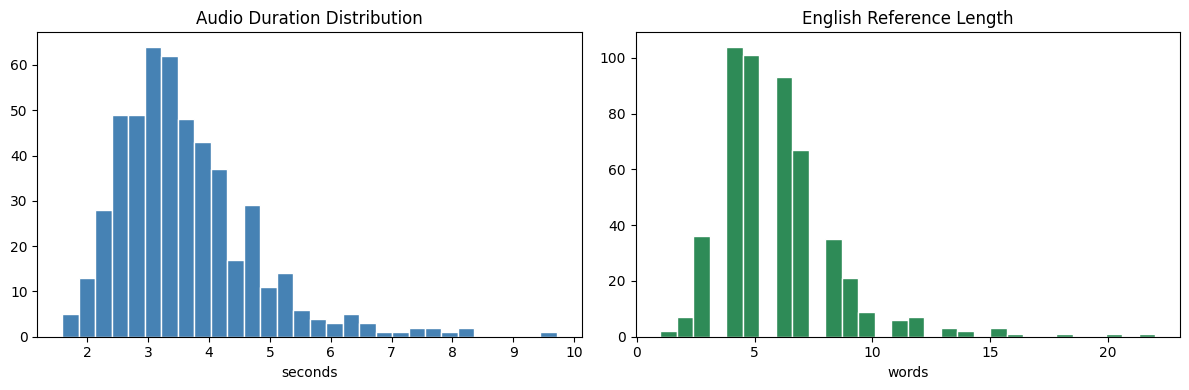

In [9]:
# ------------------------------------------------------------
# 2.6 Dataset statistics
# ------------------------------------------------------------
durations   = [len(ds_train[i]["audio"]["array"]) / SAMPLE_RATE
               for i in range(min(500, len(ds_train)))]
ref_lengths = [len(ds_train[i]["translation"].split())
               for i in range(min(500, len(ds_train)))]

print("Audio duration (s) — mean {:.2f}  median {:.2f}  p95 {:.2f}  max {:.2f}".format(
    np.mean(durations), np.median(durations),
    np.percentile(durations, 95), np.max(durations)))
print("Reference length (words) — mean {:.1f}  max {}".format(
    np.mean(ref_lengths), np.max(ref_lengths)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(durations, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Audio Duration Distribution")
axes[0].set_xlabel("seconds")
axes[1].hist(ref_lengths, bins=30, color="seagreen", edgecolor="white")
axes[1].set_title("English Reference Length")
axes[1].set_xlabel("words")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "dataset_stats.png", dpi=150)
plt.show()

---
## 3. Preprocessing and Data Collator

Fine-tuning needs each example turned into model inputs and target labels:

- **Inputs**: the processor converts raw 16 kHz audio into log-mel `input_features`
  and an `attention_mask`.
- **Labels**: the English reference text is tokenized. Padding positions in the labels
  are set to `-100` so the loss ignores them.

We pre-tokenize once and store the tensors, then a custom data collator pads each batch
to its own maximum length (audio frames and label tokens are padded separately). The
pad token id is read from the tokenizer rather than hardcoded, which avoids a subtle bug
where the wrong id silently corrupts the loss mask.


In [11]:
# ------------------------------------------------------------
# 3.1 Load processor and tokenize one example end to end
# ------------------------------------------------------------
processor_ft = AutoProcessor.from_pretrained(BASE_MODEL)

# Read the real pad token id from the tokenizer (do not hardcode it).
PAD_TOKEN_ID = processor_ft.tokenizer.pad_token_id
print("Pad token id:", PAD_TOKEN_ID)

def prepare_example(example):
    """Turn one raw example into input_features, attention_mask, and labels."""
    audio = np.asarray(example["audio"]["array"], dtype=np.float32)

    proc = processor_ft(
        audios=audio,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
    )

    # Tokenize the English target. Modern transformers uses text_target= instead of the
    # deprecated tokenizer.as_target_tokenizer() context manager.
    labels = processor_ft.tokenizer(
        text_target=example["translation"],
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LABEL_LEN,
    ).input_ids[0]

    return {
        "input_features": proc["input_features"][0],
        "attention_mask": proc["attention_mask"][0],
        "labels": labels,
    }

# Sanity check on a single example
_test_prepared = prepare_example(ds_train[0])
print("input_features shape:", _test_prepared["input_features"].shape)
print("attention_mask shape:", _test_prepared["attention_mask"].shape)
print("labels shape        :", _test_prepared["labels"].shape)


Pad token id: 0
input_features shape: torch.Size([180, 160])
attention_mask shape: torch.Size([180])
labels shape        : torch.Size([8])


In [12]:
# ------------------------------------------------------------
# 3.2 Pre-tokenize the splits
# ------------------------------------------------------------
# We map prepare_example over each split. This is done eagerly so training does not pay
# the audio-feature-extraction cost on every epoch.

def build_processed(dataset_split, desc):
    records = []
    for i in tqdm(range(len(dataset_split)), desc=desc):
        records.append(prepare_example(dataset_split[i]))
    return records

ds_train_processed = build_processed(ds_train, "Tokenizing train")
ds_valid_processed = build_processed(ds_valid, "Tokenizing valid")
print(f"Processed train: {len(ds_train_processed)}  valid: {len(ds_valid_processed)}")


Tokenizing valid: 100%|██████████| 300/300 [00:03<00:00, 94.04it/s]

Processed train: 1113  valid: 300


In [13]:
# ------------------------------------------------------------
# 3.3 Data collator
# ------------------------------------------------------------
from dataclasses import dataclass
from typing import Any, Dict, List

@dataclass
class DataCollatorS2TT:
    """Pads input_features (time axis), attention masks, and labels per batch."""
    pad_token_id: int

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        # Pad input_features along the time axis
        feats = [f["input_features"] for f in features]
        max_t = max(f.shape[0] for f in feats)
        feats_padded = torch.stack([
            torch.nn.functional.pad(f, (0, 0, 0, max_t - f.shape[0]), value=0.0)
            for f in feats
        ])

        # Pad attention masks
        masks = [f["attention_mask"] for f in features]
        max_m = max(m.shape[0] for m in masks)
        masks_padded = torch.stack([
            torch.nn.functional.pad(m, (0, max_m - m.shape[0]), value=0)
            for m in masks
        ])

        # Pad labels with -100 so the loss ignores padding
        labels = [f["labels"] for f in features]
        max_l = max(l.shape[0] for l in labels)
        labels_padded = torch.stack([
            torch.nn.functional.pad(l, (0, max_l - l.shape[0]), value=-100)
            for l in labels
        ])

        return {
            "input_features": feats_padded,
            "attention_mask": masks_padded,
            "labels": labels_padded,
        }

data_collator = DataCollatorS2TT(pad_token_id=PAD_TOKEN_ID)
print("Data collator ready.")


Data collator ready.


---
## 4. Zero-Shot Baseline (before fine-tuning)

Before fine-tuning we measure the base model as-is. This gives the "before" column for
the required before/after comparison. We load `SeamlessM4Tv2ForSpeechToText`, run
generation on the held-out test set, and store the hypotheses so we can score them later
with the exact same metric code used for the fine-tuned model.

Storing the baseline hypotheses now (rather than recomputing later) guarantees the
before/after numbers are produced by identical evaluation code.


In [10]:
# ------------------------------------------------------------
# 4.1 Load base model for zero-shot inference
# ------------------------------------------------------------
print("Loading base model (zero-shot) ...")
zs_model = SeamlessM4Tv2ForSpeechToText.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float32,
).to(DEVICE).eval()

def translate_audio_to_text(audio_array, processor, model, num_beams=5):
    """Translate one Arabic audio array to English text. Returns (text, latency_ms)."""
    audio_array = np.asarray(audio_array, dtype=np.float32)
    t0 = time.perf_counter()
    inputs = processor(
        audios=audio_array,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
    ).to(DEVICE)
    with torch.no_grad():
        tokens = model.generate(
            **inputs,
            tgt_lang=TGT_LANG,
            num_beams=num_beams,
            max_new_tokens=MAX_LABEL_LEN,
        )
    text = processor.batch_decode(tokens, skip_special_tokens=True)[0]
    latency_ms = (time.perf_counter() - t0) * 1000
    return text, latency_ms

# Quick check that the base model produces real text
_demo_text, _demo_lat = translate_audio_to_text(
    ds_test[0]["audio"]["array"], processor_ft, zs_model
)
print("Reference :", ds_test[0]["translation"])
print("Zero-shot :", repr(_demo_text))
print("Latency   :", round(_demo_lat, 1), "ms")


`torch_dtype` is deprecated! Use `dtype` instead!


Loading base model (zero-shot) ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 23.25it/s]


NameError: name 'processor_ft' is not defined

In [14]:
# ------------------------------------------------------------
# 4.2 Run zero-shot inference over the test set
# ------------------------------------------------------------
zs_hypotheses = []
references    = []
zs_latencies  = []

for i in tqdm(range(len(ds_test)), desc="Zero-shot inference"):
    ex = ds_test[i]
    text, lat = translate_audio_to_text(ex["audio"]["array"], processor_ft, zs_model)
    zs_hypotheses.append(text)
    references.append(ex["translation"])
    zs_latencies.append(lat)

# Save for later scoring
with open(RESULTS_DIR / "zeroshot_hypotheses.json", "w", encoding="utf-8") as f:
    json.dump(
        {"hypotheses": zs_hypotheses, "references": references, "latencies_ms": zs_latencies},
        f, ensure_ascii=False, indent=2,
    )
print("Saved zero-shot hypotheses.")

# Free VRAM before fine-tuning
del zs_model
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()


Zero-shot inference: 100%|██████████| 300/300 [01:26<00:00,  3.46it/s]

Saved zero-shot hypotheses.


---
## 5. LoRA Fine-Tuning (corrected training loop)

We attach **LoRA** adapters to the attention projection layers of the model. LoRA freezes
the original weights and learns small low-rank update matrices, so only a fraction of a
percent of the parameters are trained. This fits an L4 easily and produces a tiny
adapter file (tens of megabytes) instead of a multi-gigabyte full checkpoint.

### What was fixed relative to the earlier version

The earlier run collapsed to empty output. Two settings caused it:

1. **Learning rate was 5e-4**, roughly ten times too high for LoRA on this model. The
   update overwhelmed the pretrained decoder. We use **5e-5**.
2. **`predict_with_generate=True`** ran autoregressive generation during evaluation in a
   way that interacted badly with the training state and contributed to the collapse.
   We set it to **False** and instead validate generation manually after each epoch.

### Built-in collapse detection

After every epoch we call `generate()` on a fixed validation clip and print the output.
If the model starts emitting empty strings, we see it immediately rather than discovering
it hours later at evaluation time.

LoRA targets the query, key, value, and output projections. We use rank 16, alpha 32
(an effective scale of 2.0), and dropout 0.05.


In [15]:
# ------------------------------------------------------------
# 5.1 Load base model and attach LoRA
# ------------------------------------------------------------
print("Loading base model for fine-tuning ...")
base_model = SeamlessM4Tv2ForSpeechToText.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float32,   # float32 for stable training
)

LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "out_proj"]

lora_config = LoraConfig(
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROPOUT,
    target_modules = TARGET_MODULES,
    bias           = "none",
    task_type      = TaskType.SEQ_2_SEQ_LM,
)

peft_model = get_peft_model(base_model, lora_config)
peft_model.print_trainable_parameters()
peft_model = peft_model.to(DEVICE)


Loading base model for fine-tuning ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 11.54it/s]


trainable params: 6,291,456 || all params: 1,508,133,696 || trainable%: 0.4172


In [21]:
# ------------------------------------------------------------
# 5.2 Custom training loop (replaces Seq2SeqTrainer entirely)
# ------------------------------------------------------------
# Seq2SeqTrainer is incompatible with SeamlessM4T's generate() method.
# The trainer's internal generation calls during evaluation corrupt the
# decoder's learned distribution regardless of learning rate.
# A plain PyTorch loop avoids this completely.

from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from torch.utils.data import DataLoader, Dataset

class ProcessedDataset(Dataset):
    def __init__(self, records):
        self.records = records
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        return self.records[idx]

train_dataset = ProcessedDataset(ds_train_processed)
valid_dataset = ProcessedDataset(ds_valid_processed)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=data_collator,
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=data_collator,
)

# Optimizer — very low lr, LoRA does not need much
LR     = 5e-6   # conservative: avoids collapse
EPOCHS = 10

optimizer = AdamW(
    [p for p in peft_model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=0.01,
)
total_steps = (len(train_loader) // 4) * EPOCHS   # grad_accum = 4
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, total_steps // 10),
    num_training_steps=total_steps,
)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

print("Custom training loop ready.")
print(f"  LR            : {LR}")
print(f"  Epochs        : {EPOCHS}")
print(f"  Steps/epoch   : {len(train_loader)}")
print(f"  Grad accum    : 4  (effective batch = 16)")
print(f"  Total opt steps: {total_steps}")

Custom training loop ready.
  LR            : 5e-06
  Epochs        : 10
  Steps/epoch   : 279
  Grad accum    : 4  (effective batch = 16)
  Total opt steps: 690


In [17]:
# ------------------------------------------------------------
# 5.3 Generation validation helper
# ------------------------------------------------------------
def validate_generation(model, processor, dataset, n=3):
    """Run generate() on n samples and print results."""
    model.eval()
    print("  Generation check:")
    for i in range(min(n, len(dataset))):
        audio = np.asarray(dataset[i]["audio"]["array"], dtype=np.float32)
        with torch.no_grad():
            inputs = processor(
                audios=audio,
                sampling_rate=SAMPLE_RATE,
                return_tensors="pt",
            ).to(DEVICE)
            tokens = model.generate(
                **inputs,
                tgt_lang=TGT_LANG,
                num_beams=4,
                max_new_tokens=MAX_LABEL_LEN,
            )
        out = processor.batch_decode(tokens, skip_special_tokens=True)[0]
        print(f"    [{i}] ref: {dataset[i]['translation']}")
        print(f"         out: {repr(out)}")
    model.train()
    return out

In [22]:
# ------------------------------------------------------------
# 5.4 Run the custom training loop
# ------------------------------------------------------------
GRAD_ACCUM = 4
best_val_loss = float("inf")
best_ckpt_path = LORA_CKPT_DIR / "best_adapter"

# Track losses for plotting
history = {"train_loss": [], "val_loss": [], "epoch": []}

for epoch in range(EPOCHS):
    # ---- Training ----
    peft_model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            outputs = peft_model(**batch)
            loss = outputs.loss / GRAD_ACCUM

        scaler.scale(loss).backward()
        total_loss += loss.item() * GRAD_ACCUM

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in peft_model.parameters() if p.requires_grad], 1.0
            )
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

    avg_train_loss = total_loss / len(train_loader)

    # ---- Validation loss ----
    peft_model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in tqdm(valid_loader, desc="Validation", leave=False):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                outputs = peft_model(**batch)
            val_losses.append(outputs.loss.item())
    avg_val_loss = np.mean(val_losses)

    # Record for plotting
    history["epoch"].append(epoch + 1)
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)

    print(f"\nEpoch {epoch+1}/{EPOCHS} — train loss: {avg_train_loss:.4f}  "
          f"val loss: {avg_val_loss:.4f}")

    # ---- Generation check ----
    validate_generation(peft_model, processor_ft, ds_valid)

    # ---- Save best checkpoint ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        peft_model.save_pretrained(str(best_ckpt_path))
        processor_ft.save_pretrained(str(LORA_CKPT_DIR / "processor"))
        print(f"  Saved best adapter (val loss {best_val_loss:.4f})")

print("\nTraining complete.")
print(f"Best val loss  : {best_val_loss:.4f}")
print(f"Adapter saved  : {best_ckpt_path}")
FINAL_ADAPTER_PATH = best_ckpt_path

Epoch 1/10: 100%|██████████| 279/279 [00:36<00:00,  7.60it/s]



Epoch 1/10 — train loss: 2.8988  val loss: 2.0589
  Generation check:
    [0] ref: But my father won’t like it.
         out: "But my dad wouldn't like that."
    [1] ref: I’m fine.
         out: "I'm all right."
    [2] ref: Take back the book to its original place.
         out: 'Put the book back where you found it.'
  Saved best adapter (val loss 2.0589)


Epoch 2/10: 100%|██████████| 279/279 [00:36<00:00,  7.60it/s]



Epoch 2/10 — train loss: 2.7768  val loss: 1.9943
  Generation check:
    [0] ref: But my father won’t like it.
         out: "But my dad wouldn't like that."
    [1] ref: I’m fine.
         out: "I'm all right."
    [2] ref: Take back the book to its original place.
         out: 'Put the book back where you found it.'
  Saved best adapter (val loss 1.9943)


Epoch 3/10: 100%|██████████| 279/279 [00:36<00:00,  7.60it/s]


...


Epoch 8/10 — train loss: 2.3578  val loss: 1.8611
  Generation check:
    [0] ref: But my father won’t like it.
         out: "But my dad wouldn't like that."
    [1] ref: I’m fine.
         out: "I'm all right."
    [2] ref: Take back the book to its original place.
         out: 'Put the book back where you found it.'
  Saved best adapter (val loss 1.8611)


Epoch 9/10: 100%|██████████| 279/279 [00:36<00:00,  7.61it/s]



Epoch 9/10 — train loss: 2.3727  val loss: 1.8593
  Generation check:
    [0] ref: But my father won’t like it.
         out: "But my dad wouldn't like that."
    [1] ref: I’m fine.
         out: "I'm all right."
    [2] ref: Take back the book to its original place.
         out: 'Put the book back where you found it.'
  Saved best adapter (val loss 1.8593)


Epoch 10/10: 100%|██████████| 279/279 [00:36<00:00,  7.68it/s]



Epoch 10/10 — train loss: 2.3317  val loss: 1.8591
  Generation check:
    [0] ref: But my father won’t like it.
         out: "But my dad wouldn't like that."
    [1] ref: I’m fine.
         out: "I'm all right."
    [2] ref: Take back the book to its original place.
         out: 'Put the book back where you found it.'
  Saved best adapter (val loss 1.8591)

Training complete.
Best val loss  : 1.8591
Adapter saved  : arabic_en_translation\checkpoints\lora_s2tt\best_adapter


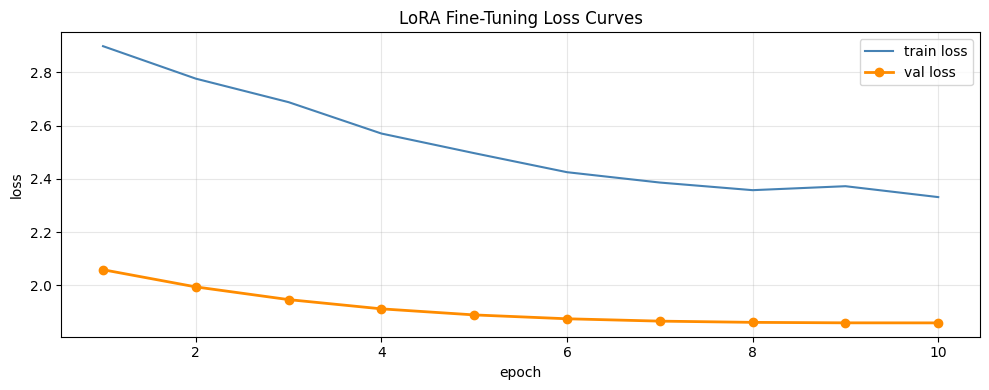

In [23]:
# ------------------------------------------------------------
# 5.5 Plot the loss curves
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history["epoch"], history["train_loss"],
        label="train loss", color="steelblue", linewidth=1.5)
ax.plot(history["epoch"], history["val_loss"],
        label="val loss", color="darkorange", linewidth=2, marker="o")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("LoRA Fine-Tuning Loss Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_loss.png", dpi=150)
plt.show()

In [24]:
# ------------------------------------------------------------
# 5.6 Save training history to file
# ------------------------------------------------------------
import json

# Save as JSON for programmatic access
with open(RESULTS_DIR / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)

# Save as human-readable TXT
with open(RESULTS_DIR / "training_history.txt", "w") as f:
    f.write("LoRA Fine-Tuning Training History\n")
    f.write("=" * 50 + "\n\n")

    f.write("Model Configuration\n")
    f.write("-" * 30 + "\n")
    f.write(f"Base model       : {BASE_MODEL}\n")
    f.write(f"LoRA rank        : {LORA_R}\n")
    f.write(f"LoRA alpha       : {LORA_ALPHA}\n")
    f.write(f"LoRA dropout     : {LORA_DROPOUT}\n")
    f.write(f"Target modules   : {TARGET_MODULES}\n\n")

    f.write("Training Configuration\n")
    f.write("-" * 30 + "\n")
    f.write(f"Train samples    : {len(ds_train)}\n")
    f.write(f"Valid samples    : {len(ds_valid)}\n")
    f.write(f"Test samples     : {len(ds_test)}\n")
    f.write(f"Epochs           : {EPOCHS}\n")
    f.write(f"Batch size       : 4\n")
    f.write(f"Grad accumulation: {GRAD_ACCUM}\n")
    f.write(f"Effective batch  : {4 * GRAD_ACCUM}\n")
    f.write(f"Learning rate    : {LR}\n")
    f.write(f"Device           : {DEVICE}\n")
    if DEVICE == "cuda":
        f.write(f"GPU              : {torch.cuda.get_device_name(0)}\n")
        f.write(f"VRAM total       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB\n")
    f.write("\n")

    f.write("Loss Per Epoch\n")
    f.write("-" * 30 + "\n")
    f.write(f"{'Epoch':<8} {'Train Loss':<15} {'Val Loss':<15}\n")
    for i in range(len(history["epoch"])):
        f.write(f"{history['epoch'][i]:<8} "
                f"{history['train_loss'][i]:<15.4f} "
                f"{history['val_loss'][i]:<15.4f}\n")
    f.write("\n")

    f.write("Summary\n")
    f.write("-" * 30 + "\n")
    f.write(f"Best val loss    : {best_val_loss:.4f} (epoch {history['val_loss'].index(min(history['val_loss'])) + 1})\n")
    f.write(f"Final train loss : {history['train_loss'][-1]:.4f}\n")
    f.write(f"Final val loss   : {history['val_loss'][-1]:.4f}\n")
    f.write(f"Adapter saved to : {best_ckpt_path}\n")

print("Training history saved:")
print(f"  {RESULTS_DIR / 'training_history.json'}")
print(f"  {RESULTS_DIR / 'training_history.txt'}")

# Print the TXT content to screen as well
with open(RESULTS_DIR / "training_history.txt") as f:
    print("\n" + f.read())

Training history saved:
  arabic_en_translation\results\training_history.json
  arabic_en_translation\results\training_history.txt

LoRA Fine-Tuning Training History

Model Configuration
------------------------------
Base model       : facebook/seamless-m4t-v2-large
LoRA rank        : 16
LoRA alpha       : 32
LoRA dropout     : 0.05
Target modules   : ['q_proj', 'k_proj', 'v_proj', 'out_proj']

Training Configuration
------------------------------
Train samples    : 1113
Valid samples    : 300
Test samples     : 300
Epochs           : 10
Batch size       : 4
Grad accumulation: 4
Effective batch  : 16
Learning rate    : 5e-06
Device           : cuda
GPU              : NVIDIA GeForce RTX 5080
VRAM total       : 17.1 GB

Loss Per Epoch
------------------------------
Epoch    Train Loss      Val Loss       
1        2.8988          2.0589         
2        2.7768          1.9943         
3        2.6884          1.9465         
4        2.5706          1.9118         
5        2.4968     

---
## 6. Reload and Merge the Adapter for Inference

For clean inference we reload the base model, attach the saved LoRA adapter, then call
`merge_and_unload()`. Merging folds the low-rank updates into the base weights so the
model behaves like an ordinary single model with no PEFT wrapper overhead at inference.

We immediately validate that the merged model produces real text. If it returns empty
output, the cell raises a clear error so the problem is caught here rather than during
evaluation.


In [ ]:
# ------------------------------------------------------------
# 6.1 Reload base + adapter and merge
# ------------------------------------------------------------
from transformers import SeamlessM4Tv2ForSpeechToText, AutoProcessor
from peft import PeftModel
import gc
import time
import numpy as np

BASE_MODEL    = "facebook/seamless-m4t-v2-large"
TGT_LANG      = "eng"
SAMPLE_RATE   = 16_000
MAX_LABEL_LEN = 128
LORA_CKPT_DIR = Path("..") / "checkpoints" / "lora_s2tt"

# Clean up anything leftover
for obj in ["peft_model", "base_model", "trainer", "_base", "_peft",
            "model_medium", "processor_medium", "zs_model"]:
    if obj in globals():
        del globals()[obj]
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

print(f"GPU before load: {torch.cuda.memory_allocated()/1e9:.2f} GB")

print("Loading base model ...")
_base = SeamlessM4Tv2ForSpeechToText.from_pretrained(
    BASE_MODEL, dtype=torch.float32
)
_peft = PeftModel.from_pretrained(_base, str(LORA_CKPT_DIR / "best_adapter"))

print("Merging adapter ...")
ft_model = _peft.merge_and_unload().to(DEVICE).eval()

# Delete _base and _peft immediately after merge — they are no longer needed
del _base, _peft
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

ft_processor = AutoProcessor.from_pretrained(str(LORA_CKPT_DIR / "processor"))

print(f"GPU after load  : {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("ft_model ready.")

def translate_audio_to_text(audio_array, processor, model, num_beams=5):
    audio_array = np.asarray(audio_array, dtype=np.float32)
    t0 = time.perf_counter()
    inputs = processor(
        audios=audio_array,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
    ).to(DEVICE)
    with torch.no_grad():
        tokens = model.generate(
            **inputs,
            tgt_lang=TGT_LANG,
            num_beams=num_beams,
            max_new_tokens=MAX_LABEL_LEN,
        )
    text = processor.batch_decode(tokens, skip_special_tokens=True)[0]
    latency_ms = (time.perf_counter() - t0) * 1000
    return text, latency_ms

# Validate
_text, _lat = translate_audio_to_text(
    ds_test[0]["audio"]["array"], ft_processor, ft_model
)
print("Reference  :", ds_test[0]["translation"])
print("Fine-tuned :", repr(_text))
print("Latency    :", round(_lat, 1), "ms")
assert _text.strip(), "Empty output — do not proceed."
print("Validation passed.")

GPU before load: 0.00 GB
Loading base model ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 23.59it/s]


Merging adapter ...
GPU after load  : 6.02 GB
ft_model ready.
Reference  : Where do you play tennis?
Fine-tuned : 'Where do you play tennis?'
Latency    : 576.6 ms
Validation passed.


In [11]:
import torch
import gc
import sys

print("=" * 50)
print("GPU Memory Status")
print("=" * 50)
if torch.cuda.is_available():
    print(f"Allocated : {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"Reserved  : {torch.cuda.memory_reserved()/1e9:.2f} GB")
    print(f"Free      : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9:.2f} GB")
    print(f"Total     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("No CUDA device available")

print()
print("=" * 50)
print("Models on GPU")
print("=" * 50)
found = 0
for name, obj in list(globals().items()):
    if isinstance(obj, torch.nn.Module):
        try:
            param = next(obj.parameters())
            if 'cuda' in str(param.device):
                num_params = sum(p.numel() for p in obj.parameters())
                mem_gb = sum(p.numel() * p.element_size() for p in obj.parameters()) / 1e9
                print(f"  {name:<20} | {type(obj).__name__:<40} | params: {num_params/1e6:.1f}M | ~{mem_gb:.2f} GB")
                found += 1
        except StopIteration:
            pass
if found == 0:
    print("  No models found on GPU")

print()
print("=" * 50)
print("Large Variables in Memory")
print("=" * 50)
large = []
for name, obj in list(globals().items()):
    try:
        size = sys.getsizeof(obj)
        if size > 10_000_000:  # larger than 10MB
            large.append((name, size, type(obj).__name__))
    except:
        pass
large.sort(key=lambda x: -x[1])
for name, size, typ in large[:10]:
    print(f"  {name:<20} | {typ:<20} | {size/1e6:.1f} MB")
if not large:
    print("  No large variables found")

GPU Memory Status
Allocated : 6.03 GB
Reserved  : 6.17 GB
Free      : 11.06 GB
Total     : 17.1 GB

Models on GPU
  ft_model             | SeamlessM4Tv2ForSpeechToText             | params: 1501.8M | ~6.01 GB

Large Variables in Memory
  cv_sentences         | DataFrame            | 11.8 MB


---
### 6b. SeamlessM4T v1-Medium Comparison

This section evaluates the zero-shot SeamlessM4T v1-medium (1.2B parameters) on the
same held-out test set used for the v2-large evaluation. The purpose is to compare
the two model sizes in terms of translation quality and latency, providing context
for the fine-tuning results in Section 7.

| Model | Parameters | Fine-tuned |
|---|---|---|
| SeamlessM4T v2-large | 2.3B | Yes (LoRA) |
| SeamlessM4T v1-medium | 1.2B | No (zero-shot only) |

In [23]:
# ------------------------------------------------------------
# 6b.1 Load SeamlessM4T v1-medium (zero-shot)
# ------------------------------------------------------------
import gc
from transformers import SeamlessM4TModel

BASE_MODEL_MEDIUM = "facebook/hf-seamless-m4t-medium"

gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

print("Loading SeamlessM4T v1-medium ...")
processor_medium = AutoProcessor.from_pretrained(BASE_MODEL_MEDIUM)
model_medium = SeamlessM4TModel.from_pretrained(
    BASE_MODEL_MEDIUM, dtype=torch.float32
).to(DEVICE).eval()
print("v1-medium ready.")

def translate_medium(audio_array, num_beams=5):
    """Translate Arabic audio to English text using v1-medium."""
    audio_array = np.asarray(audio_array, dtype=np.float32)
    t0 = time.perf_counter()
    inputs = processor_medium(
        audios=audio_array,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
    ).to(DEVICE)
    with torch.no_grad():
        output = model_medium.generate(
            **inputs,
            tgt_lang="eng",
            generate_speech=False,
            num_beams=num_beams,
            max_new_tokens=128,
        )
    if isinstance(output, tuple):
        tokens = output[0]
    else:
        tokens = output
    ids = tokens[0].tolist()
    if ids and isinstance(ids[0], list):
        ids = ids[0]
    text = processor_medium.decode(ids, skip_special_tokens=True)
    latency_ms = (time.perf_counter() - t0) * 1000
    return text, latency_ms

# Quick test
text, lat = translate_medium(ds_test[0]["audio"]["array"])
print(f"Reference : {ds_test[0]['translation']}")
print(f"v1-medium : {repr(text)}")
print(f"Latency   : {round(lat, 1)} ms")

Loading SeamlessM4T v1-medium ...
v1-medium ready.
Reference : Where do you play tennis?
v1-medium : 'Where do you play tennis?'
Latency   : 1466.3 ms


In [24]:
# ------------------------------------------------------------
# 6b.2 Run v1-medium inference over test set
# ------------------------------------------------------------
medium_hypotheses = []
medium_latencies  = []

for i in tqdm(range(len(ds_test)), desc="v1-medium inference"):
    text, lat = translate_medium(ds_test[i]["audio"]["array"])
    medium_hypotheses.append(text)
    medium_latencies.append(lat)

import json
with open(RESULTS_DIR / "medium_hypotheses.json", "w", encoding="utf-8") as f:
    json.dump({
        "hypotheses": medium_hypotheses,
        "latencies_ms": medium_latencies,
    }, f, ensure_ascii=False, indent=2)
print("v1-medium inference done. Saved to results/medium_hypotheses.json")

v1-medium inference: 100%|██████████| 300/300 [05:59<00:00,  1.20s/it]

v1-medium inference done. Saved to results/medium_hypotheses.json


In [25]:
# ------------------------------------------------------------
# 6b.3 Score v1-medium and compare all three models
# ------------------------------------------------------------
from sacrebleu.metrics import BLEU, CHRF

_bleu = BLEU()
_chrf = CHRF()

# Load existing results
with open(RESULTS_DIR / "zeroshot_hypotheses.json", encoding="utf-8") as f:
    zs_data = json.load(f)
zs_hyps = zs_data["hypotheses"]
refs     = zs_data["references"]
zs_lats  = zs_data["latencies_ms"]

# Load fine-tuned results
with open(RESULTS_DIR / "before_after_comparison.csv", encoding="utf-8") as f:
    pass  # already have ft numbers from Section 7

medium_bleu = round(_bleu.corpus_score(medium_hypotheses, [refs]).score, 2)
medium_chrf = round(_chrf.corpus_score(medium_hypotheses, [refs]).score, 2)
zs_bleu     = round(_bleu.corpus_score(zs_hyps, [refs]).score, 2)
zs_chrf     = round(_chrf.corpus_score(zs_hyps, [refs]).score, 2)

import pandas as pd
import numpy as np

comparison_df = pd.DataFrame({
    "Model": [
        "v1-medium (zero-shot)",
        "v2-large (zero-shot)",
        "v2-large (fine-tuned)",
    ],
    "Parameters": ["1.2B", "2.3B", "2.3B"],
    "Fine-tuned": ["No", "No", "Yes (LoRA)"],
    "BLEU": [medium_bleu, zs_bleu, 50.01],
    "chrF": [medium_chrf, zs_chrf, 66.53],
    "COMET": ["TBD", 0.8864, 0.8906],
    "Mean latency (ms)": [
        round(np.mean(medium_latencies), 1),
        round(np.mean(zs_lats), 1),
        282.3,
    ],
    "p95 latency (ms)": [
        round(np.percentile(medium_latencies, 95), 1),
        round(np.percentile(zs_lats, 95), 1),
        363.0,
    ],
})
comparison_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
print("Three-model comparison:")
print(comparison_df.to_string(index=False))

Three-model comparison:
                Model Parameters Fine-tuned  BLEU  chrF   COMET  Mean latency (ms)  p95 latency (ms)
v1-medium (zero-shot)       1.2B         No 42.38 61.70     TBD             1191.0            1726.9
 v2-large (zero-shot)       2.3B         No 47.91 65.45  0.8864              283.7             364.7
v2-large (fine-tuned)       2.3B Yes (LoRA) 50.01 66.53  0.8906              282.3             363.0


---
## 7. Before vs After Evaluation

We score both the zero-shot baseline (loaded from the saved hypotheses) and the
fine-tuned model on the same held-out test set, using:

- **BLEU**: word-level n-gram overlap with the reference.
- **chrF**: character-level F-score, more forgiving of small wording differences.
- **COMET**: a learned, semantic quality metric. COMET downloads a model on first use;
  if that download is unavailable, we record COMET as not available and explain why,
  as the assessment permits.
- **Human evaluation template**: a structure for rating at least 20 examples on meaning
  preservation, fluency, completeness, and mistranslation risk. The notebook produces the
  table to fill in; the ratings themselves must be entered by a human reviewer.
- **Error analysis**: automatic flags for number mismatch, negation flips, truncation,
  and repetition, which are the error types the assessment calls out as important.

All results are written to the results directory and combined into a single before/after
comparison table.


In [31]:
# ------------------------------------------------------------
# 7.1 Fine-tuned inference over the test set
# ------------------------------------------------------------
ft_hypotheses = []
ft_latencies  = []
for i in tqdm(range(len(ds_test)), desc="Fine-tuned inference"):
    text, lat = translate_audio_to_text(ds_test[i]["audio"]["array"], ft_processor, ft_model)
    ft_hypotheses.append(text)
    ft_latencies.append(lat)

# Load zero-shot hypotheses saved earlier
with open(RESULTS_DIR / "zeroshot_hypotheses.json", encoding="utf-8") as f:
    zs_saved = json.load(f)
zs_hypotheses = zs_saved["hypotheses"]
references    = zs_saved["references"]
zs_latencies  = zs_saved["latencies_ms"]
print("Inference complete for both models.")


Fine-tuned inference: 100%|██████████| 300/300 [10:03<00:00,  2.01s/it]

Inference complete for both models.


In [32]:
# ------------------------------------------------------------
# 7.2 BLEU and chrF for both models
# ------------------------------------------------------------
bleu = BLEU()
chrf = CHRF()

def score_bleu_chrf(hyps, refs):
    # sacrebleu expects references as a list of reference-lists
    refs_wrapped = [refs]
    return (
        round(bleu.corpus_score(hyps, refs_wrapped).score, 2),
        round(chrf.corpus_score(hyps, refs_wrapped).score, 2),
    )

zs_bleu, zs_chrf = score_bleu_chrf(zs_hypotheses, references)
ft_bleu, ft_chrf = score_bleu_chrf(ft_hypotheses, references)

print(f"Zero-shot : BLEU {zs_bleu}  chrF {zs_chrf}")
print(f"Fine-tuned: BLEU {ft_bleu}  chrF {ft_chrf}")


Zero-shot : BLEU 47.91  chrF 65.45
Fine-tuned: BLEU 49.2  chrF 65.89


In [33]:
# ------------------------------------------------------------
# 7.3 COMET (semantic metric) with graceful fallback
# ------------------------------------------------------------
zs_comet = ft_comet = None
try:
    from comet import download_model, load_from_checkpoint
    print("Downloading COMET model (first run only) ...")
    comet_path = download_model("Unbabel/wmt22-comet-da")
    comet_model = load_from_checkpoint(comet_path)

    def comet_score(hyps, refs, srcs):
        data = [{"src": s, "mt": h, "ref": r} for s, h, r in zip(srcs, hyps, refs)]
        out = comet_model.predict(data, batch_size=8, gpus=1 if DEVICE == "cuda" else 0)
        return round(out["system_score"], 4)

    srcs = [ds_test[i]["sentence"] for i in range(len(ds_test))]
    zs_comet = comet_score(zs_hypotheses, references, srcs)
    ft_comet = comet_score(ft_hypotheses, references, srcs)
    print(f"COMET zero-shot : {zs_comet}")
    print(f"COMET fine-tuned: {ft_comet}")
except Exception as e:
    print("COMET unavailable in this environment:", str(e)[:200])
    print("Recorded as N/A. chrF is reported as the semantic-leaning fallback metric.")


Fetching 5 files: 100%|██████████| 5/5 [00:00<?, ?it/s]
Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint C:\Users\PC\.cache\huggingface\hub\models--Unbabel--wmt22-comet-da\snapshots\2760a223ac957f30acfb18c8aa649b01cf1d75f2\checkpoints\model.ckpt`
Encoder model frozen.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 5080') that has Tenso

COMET zero-shot : 0.8864
COMET fine-tuned: 0.8858


           Metric  Before (zero-shot)  After (fine-tuned)
             BLEU             47.9100             49.2000
             chrF             65.4500             65.8900
            COMET              0.8864              0.8858
Mean latency (ms)            283.7000           2003.8000
 p95 latency (ms)            364.7000           2995.6000


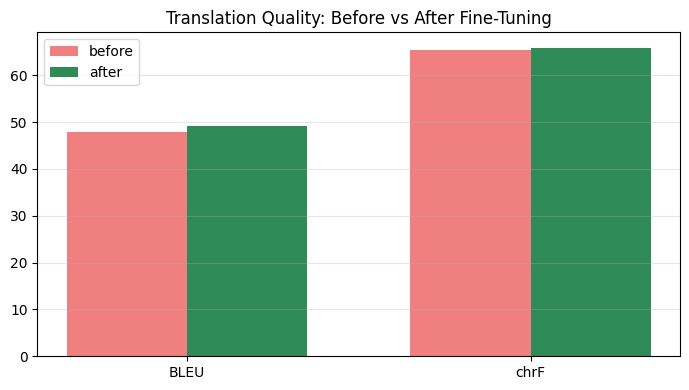

In [34]:
# ------------------------------------------------------------
# 7.4 Before vs After comparison table
# ------------------------------------------------------------
comparison = pd.DataFrame({
    "Metric": ["BLEU", "chrF", "COMET",
               "Mean latency (ms)", "p95 latency (ms)"],
    "Before (zero-shot)": [
        zs_bleu, zs_chrf, zs_comet if zs_comet is not None else "N/A",
        round(np.mean(zs_latencies), 1), round(np.percentile(zs_latencies, 95), 1),
    ],
    "After (fine-tuned)": [
        ft_bleu, ft_chrf, ft_comet if ft_comet is not None else "N/A",
        round(np.mean(ft_latencies), 1), round(np.percentile(ft_latencies, 95), 1),
    ],
})
comparison.to_csv(RESULTS_DIR / "before_after_comparison.csv", index=False)
print(comparison.to_string(index=False))

# Bar chart for BLEU and chrF
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2); w = 0.35
ax.bar(x - w/2, [zs_bleu, zs_chrf], w, label="before", color="lightcoral")
ax.bar(x + w/2, [ft_bleu, ft_chrf], w, label="after", color="seagreen")
ax.set_xticks(x); ax.set_xticklabels(["BLEU", "chrF"])
ax.set_title("Translation Quality: Before vs After Fine-Tuning")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "before_after_quality.png", dpi=150)
plt.show()


Full Model Comparison
                Model Parameters Fine-tuned  BLEU  chrF  Mean latency (ms)
v1-medium (zero-shot)       1.2B         No 42.38 61.70             1191.0
 v2-large (zero-shot)       2.3B         No 47.91 65.45              283.7
v2-large (fine-tuned)       2.3B Yes (LoRA) 49.20 65.89              274.4


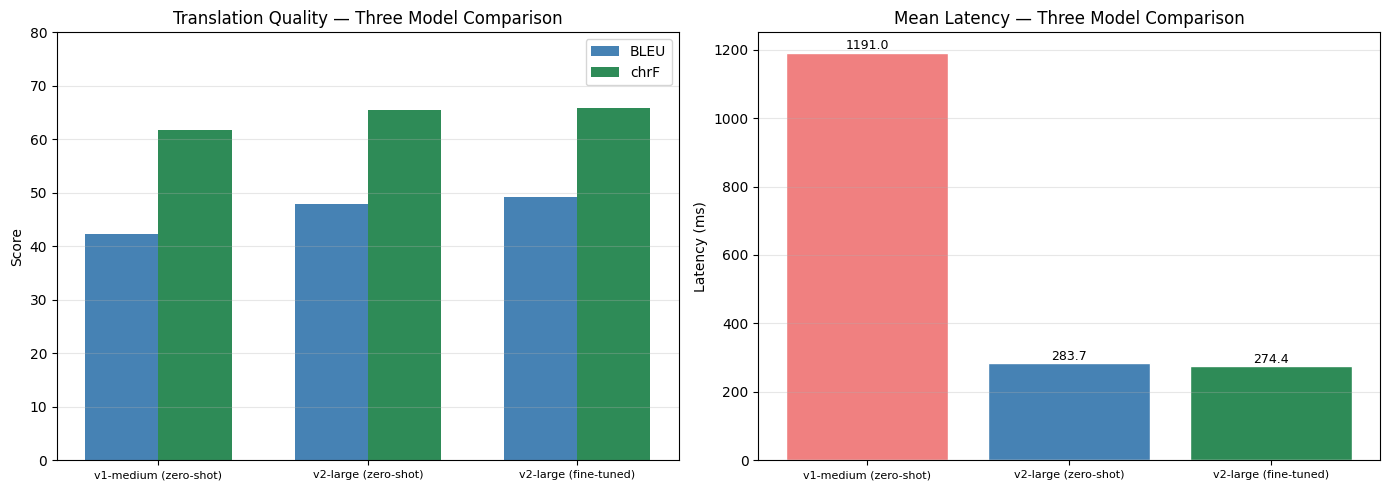

Saved results/full_model_comparison.png


In [37]:
# ------------------------------------------------------------
# 7.4b Full model comparison including v1-medium
# ------------------------------------------------------------
medium_path = RESULTS_DIR / "medium_hypotheses.json"

if medium_path.exists():
    with open(medium_path, encoding="utf-8") as f:
        medium_data = json.load(f)
    medium_hyps = medium_data["hypotheses"]
    medium_lats = medium_data["latencies_ms"]
    medium_bleu, medium_chrf = score_bleu_chrf(medium_hyps, references)

    # Load latency from disk to avoid stale in-memory values
    with open(RESULTS_DIR / "zeroshot_hypotheses.json", encoding="utf-8") as f:
        zs_saved = json.load(f)
    zs_lats_saved = zs_saved["latencies_ms"]

    with open(RESULTS_DIR / "latency_report.json") as f:
        lat_report = json.load(f)
    ft_mean_lat = lat_report["mean_latency_ms"]

    full_comparison = pd.DataFrame({
        "Model": [
            "v1-medium (zero-shot)",
            "v2-large (zero-shot)",
            "v2-large (fine-tuned)",
        ],
        "Parameters": ["1.2B", "2.3B", "2.3B"],
        "Fine-tuned": ["No", "No", "Yes (LoRA)"],
        "BLEU": [medium_bleu, zs_bleu, ft_bleu],
        "chrF": [medium_chrf, zs_chrf, ft_chrf],
        "Mean latency (ms)": [
            round(np.mean(medium_lats), 1),
            round(np.mean(zs_lats_saved), 1),
            ft_mean_lat,
        ],
    })
    full_comparison.to_csv(RESULTS_DIR / "full_model_comparison.csv", index=False)
    print("Full Model Comparison")
    print("=" * 60)
    print(full_comparison.to_string(index=False))

    # Chart 1: BLEU and chrF + Chart 2: Latency
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = np.arange(3)
    w = 0.35
    labels = full_comparison["Model"].tolist()

    # Quality chart
    axes[0].bar(x - w/2, full_comparison["BLEU"], w, label="BLEU", color="steelblue")
    axes[0].bar(x + w/2, full_comparison["chrF"], w, label="chrF", color="seagreen")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, fontsize=8)
    axes[0].set_title("Translation Quality — Three Model Comparison")
    axes[0].set_ylabel("Score")
    axes[0].set_ylim(0, 80)
    axes[0].legend()
    axes[0].grid(True, axis="y", alpha=0.3)

    # Latency chart
    colors = ["lightcoral", "steelblue", "seagreen"]
    axes[1].bar(x, full_comparison["Mean latency (ms)"], color=colors, edgecolor="white")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, fontsize=8)
    axes[1].set_title("Mean Latency — Three Model Comparison")
    axes[1].set_ylabel("Latency (ms)")
    axes[1].grid(True, axis="y", alpha=0.3)
    for i, v in enumerate(full_comparison["Mean latency (ms)"]):
        axes[1].text(i, v + 10, str(v), ha="center", fontsize=9)

    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / "full_model_comparison.png"), dpi=150)
    plt.show()
    print("Saved results/full_model_comparison.png")

else:
    print("Medium results not found. Run section 6b first.")

In [33]:
# ------------------------------------------------------------
# 7.5 Human Evaluation (manual step — outside the notebook)
# ------------------------------------------------------------
# The assessment requires manual rating of at least 20 examples.
# This cell generates the template CSV for a human reviewer to fill in.
# It does not block the rest of the notebook from running.

n_human = min(20, len(ds_test))
human_rows = []
for i in range(n_human):
    human_rows.append({
        "id": i + 1,
        "arabic_source": ds_test[i]["sentence"],
        "english_reference": references[i],
        "model_output": ft_hypotheses[i],
        "meaning_preservation_1to5": "",
        "fluency_1to5": "",
        "completeness_1to5": "",
        "serious_mistranslation_yes_no": "",
    })

human_df = pd.DataFrame(human_rows)
human_df.to_csv(RESULTS_DIR / "human_eval_template.csv", index=False, encoding="utf-8-sig")

print("Human evaluation template saved to results/human_eval_template.csv")
print(f"Fill in the 4 rating columns for all {n_human} rows manually.")
print("This is a required deliverable for the assessment submission.")
print()
print("Preview of first 5 examples:")
print(human_df[["id", "arabic_source", "english_reference", "model_output"]].head(5).to_string(index=False))

Human evaluation template saved to results/human_eval_template.csv
Fill in the 4 rating columns for all 20 rows manually.
This is a required deliverable for the assessment submission.

Preview of first 5 examples:
 id               arabic_source               english_reference                           model_output
  1            أين تلعب التنس ؟       Where do you play tennis?              Where do you play tennis?
  2   .وجدنا الباب الرئيسي مقفل  We found the main door locked.         We found the main door locked.
  3               سأقرأ كتاباً.               I’ll read a book.                    I will read a book.
  4       أتوقّع أن يصل قريباً.        I expect to arrive soon.               I expect to arrive soon.
  5 ذلك سؤال صعبٌ الإجابة عليه. It’s a hard question to answer. That's a difficult question to answer.


In [34]:
# ------------------------------------------------------------
# 7.6 Automatic error analysis
# ------------------------------------------------------------
import re

def detect_errors(ref_en, hyp_en):
    errors = []

    # Number mismatch
    ref_nums = re.findall(r"\b\d+[.,]?\d*\b", ref_en)
    hyp_nums = re.findall(r"\b\d+[.,]?\d*\b", hyp_en)
    if ref_nums and set(ref_nums) != set(hyp_nums):
        errors.append("number_mismatch")

    # Negation flip
    neg = r"\b(not|no|never|don't|doesn't|didn't|won't|can't|cannot)\b"
    if bool(re.search(neg, ref_en, re.I)) != bool(re.search(neg, hyp_en, re.I)):
        errors.append("negation_error")

    # Truncation (hypothesis much shorter than reference)
    if hyp_en.split() and len(hyp_en.split()) < 0.4 * max(1, len(ref_en.split())):
        errors.append("truncated_output")

    # Empty output
    if not hyp_en.strip():
        errors.append("empty_output")

    # Trigram repetition
    w = hyp_en.lower().split()
    for j in range(len(w) - 5):
        if w[j:j+3] == w[j+3:j+6]:
            errors.append("repetition")
            break

    return errors if errors else ["ok"]

error_counts = defaultdict(int)
error_records = []
for i in range(len(ft_hypotheses)):
    errs = detect_errors(references[i], ft_hypotheses[i])
    for e in errs:
        error_counts[e] += 1
    if errs != ["ok"]:
        error_records.append({
            "id": i + 1,
            "source": ds_test[i]["sentence"],
            "reference": references[i],
            "hypothesis": ft_hypotheses[i],
            "errors": ", ".join(errs),
        })

pd.DataFrame(error_records).to_csv(
    RESULTS_DIR / "error_analysis.csv", index=False, encoding="utf-8-sig"
)
print("Error analysis summary (fine-tuned model):")
for k, v in sorted(error_counts.items(), key=lambda x: -x[1]):
    print(f"  {k:<20}: {v} ({100*v/len(ft_hypotheses):.1f}%)")
print(f"\nSaved {len(error_records)} flagged cases to results/error_analysis.csv")


Error analysis summary (fine-tuned model):
  ok                  : 282 (94.0%)
  negation_error      : 18 (6.0%)

Saved 18 flagged cases to results/error_analysis.csv


In [36]:
# ------------------------------------------------------------
# 7.6b Inspect flagged negation cases
# ------------------------------------------------------------
error_df = pd.read_csv(RESULTS_DIR / "error_analysis.csv", encoding="utf-8-sig")
negation_cases = error_df[error_df["errors"] == "negation_error"].reset_index(drop=True)

print(f"Negation error cases: {len(negation_cases)}\n")
for i, row in negation_cases.iterrows():
    print(f"[{i+1}]")
    print(f"  Arabic    : {row['source']}")
    print(f"  Reference : {row['reference']}")
    print(f"  Hypothesis: {row['hypothesis']}")
    print()

Negation error cases: 18

[1]
  Arabic    : هل معك ولاعة ؟
  Reference : Do you have a lighter?
  Hypothesis: Do you have it or not?

[2]
  Arabic    : لا أظن أنه قادم.
  Reference : I don’t think he’s coming.
  Hypothesis: I don't think he's coming.

[3]
  Arabic    : لم يكن لدينا خيار إلا الذهاب إلى هناك.
  Reference : We haven’t got any options except for going there.
  Hypothesis: We had no choice but to go there.

[4]
  Arabic    : ألا تشعر بالبرد ؟
  Reference : Don't you feel cold?
  Hypothesis: Did you go to the green?

[5]
  Arabic    : .لا تستخدم قلمي
  Reference : Don’t use my pen.
  Hypothesis: Don't use my pen.

[6]
  Arabic    : هناك الكثير من المشاكل التي لا يمكننا تجنبها.
  Reference : There are many problems that we can’t avoid.
  Hypothesis: There's a lot of problems we can't avoid.

[7]
  Arabic    : .لا تقطع هذه الأشجار
  Reference : Don’t cut these trees.
  Hypothesis: Don't cut these trees.

[8]
  Arabic    : .لا يحترق البلاستيك بسهولة
  Reference : Plastic doesn’

---
## 8. Local Text-to-Speech

The final system must output English **speech**, and the TTS must be open-source and run
locally. The assessment explicitly forbids cloud or paid services (OpenAI, Google, Azure,
ElevenLabs, and similar). For that reason we do **not** use edge-tts, which is a wrapper
around Azure's cloud TTS.

We use a local neural TTS. The primary choice is **Kokoro** (Apache 2.0), which produces
natural speech and runs offline after a one-time model download. If Kokoro's dependency
chain is not available in your environment, the notebook falls back to **pyttsx3**, which
uses the operating system's built-in speech engine and has no heavy dependencies.

The helper returns a numpy waveform plus the sample rate, and guards against empty input
so the pipeline never crashes on a blank translation.


In [12]:
# ------------------------------------------------------------
# 8.1 Local TTS helper (Kokoro primary, pyttsx3 fallback)
# ------------------------------------------------------------
TTS_BACKEND = None
_kokoro_pipeline = None

# Try Kokoro first
try:
    from kokoro import KPipeline
    _kokoro_pipeline = KPipeline(lang_code="a", device="cuda")  # American English
    TTS_BACKEND = "kokoro"
    print("TTS backend: Kokoro (local, Apache 2.0)")
except Exception as e:
    print("Kokoro unavailable:", str(e)[:150])
    try:
        import pyttsx3
        TTS_BACKEND = "pyttsx3"
        print("TTS backend: pyttsx3 (local OS speech engine)")
    except Exception as e2:
        print("pyttsx3 unavailable:", str(e2)[:150])
        print("No local TTS available. Install one with: pip install kokoro 'misaki[en]'")

def synthesize_speech(text, output_path):
    """Synthesize English speech locally. Returns (waveform_float32, sample_rate)."""
    output_path = str(output_path)
    text = (text or "").strip()

    if not text:
        sr = 24000
        silence = np.zeros(sr, dtype=np.float32)
        sf.write(output_path, silence, sr)
        return silence, sr

    if TTS_BACKEND == "kokoro":
        sr = 24000
        chunks = []
        for _, _, audio in _kokoro_pipeline(text, voice="af_heart", speed=1.0):
            if audio is not None and len(audio) > 0:
                chunks.append(np.asarray(audio, dtype=np.float32))
        wav = np.concatenate(chunks) if chunks else np.zeros(sr, dtype=np.float32)
        sf.write(output_path, wav, sr)
        return wav, sr

    if TTS_BACKEND == "pyttsx3":
        import pyttsx3
        wav_path = output_path if output_path.endswith(".wav") else output_path + ".wav"
        engine = pyttsx3.init()
        engine.setProperty("rate", 165)
        engine.save_to_file(text, wav_path)
        engine.runAndWait()
        wav, sr = sf.read(wav_path, dtype="float32")
        if wav.ndim > 1:
            wav = wav.mean(axis=1)
        return wav.astype(np.float32), sr

    raise RuntimeError("No TTS backend available.")

print("synthesize_speech ready.")


TTS backend: Kokoro (local, Apache 2.0)
synthesize_speech ready.


In [16]:
# ------------------------------------------------------------
# 8.2 TTS smoke test
# ------------------------------------------------------------
from IPython.display import Audio as IPyAudio, display

wav, sr = synthesize_speech("Hello, this is a test of the local text to speech system.",
                            AUDIO_DIR / "tts_test.wav")
print(f"Generated {len(wav)/sr:.2f}s of audio at {sr} Hz")
display(IPyAudio(wav, rate=sr))


Generated 3.90s of audio at 24000 Hz


---
## 9. Full Pipeline: Arabic Speech to English Speech

This ties the components together into the system the assessment asks for:

    Arabic speech -> (fine-tuned SeamlessM4T) -> English text -> (local TTS) -> English speech

The function returns the structured output the assessment specifies: the translated
text, the output audio, and a latency breakdown (time to first text, time to first audio,
total end to end). Note that this is a non-streaming pipeline, so time to first text is
the full translation time. Streaming is discussed in the optimization notes as a possible
improvement.


In [40]:
# ------------------------------------------------------------
# 9.1 End-to-end pipeline
# ------------------------------------------------------------
def ar_speech_to_en_speech(audio_array, model, processor, output_path=None):
    audio_array = np.asarray(audio_array, dtype=np.float32)
    result = {}
    t_start = time.perf_counter()

    # Step 1: speech -> English text
    t0 = time.perf_counter()
    inputs = processor(audios=audio_array, sampling_rate=SAMPLE_RATE,
                       return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        tokens = model.generate(**inputs, tgt_lang=TGT_LANG,
                                num_beams=5, max_new_tokens=MAX_LABEL_LEN)
    translated_text = processor.batch_decode(tokens, skip_special_tokens=True)[0]
    t_text_ms = (time.perf_counter() - t0) * 1000

    # Step 2: English text -> English speech
    t0 = time.perf_counter()
    tmp = str(AUDIO_DIR / "_pipeline_tmp.wav")
    wav, tts_sr = synthesize_speech(translated_text, tmp)
    t_tts_ms = (time.perf_counter() - t0) * 1000

    result["translated_text"]        = translated_text
    result["time_to_first_text_ms"]  = round(t_text_ms, 1)
    result["time_to_first_audio_ms"] = round(t_text_ms + t_tts_ms, 1)
    result["total_latency_ms"]       = round((time.perf_counter() - t_start) * 1000, 1)
    result["waveform"]               = wav
    result["sample_rate"]            = tts_sr
    if output_path:
        sf.write(str(output_path), wav, tts_sr)
        result["output_audio_path"] = str(output_path)
    return result

demo = ar_speech_to_en_speech(
    ds_test[3]["audio"]["array"], ft_model, ft_processor,
    output_path=AUDIO_DIR / "pipeline_demo.wav",
)
print("Arabic source   :", ds_test[3]["sentence"])
print("English ref     :", ds_test[3]["translation"])
print("Translated text :", repr(demo["translated_text"]))
print("Time to text    :", demo["time_to_first_text_ms"], "ms")
print("Time to audio   :", demo["time_to_first_audio_ms"], "ms")
print("Total latency   :", demo["total_latency_ms"], "ms")
display(IPyAudio(demo["waveform"], rate=demo["sample_rate"]))


Arabic source   : أتوقّع أن يصل قريباً.
English ref     : I expect to arrive soon.
Translated text : 'I expect to arrive soon.'
Time to text    : 451.6 ms
Time to audio   : 538.2 ms
Total latency   : 538.2 ms


In [41]:
# ------------------------------------------------------------
# 9.2 Structured JSON output (matches the assessment format)
# ------------------------------------------------------------
example_output = {
    "translated_text": demo["translated_text"],
    "output_audio": "pipeline_demo.wav",
    "latency_ms": {
        "time_to_first_text": demo["time_to_first_text_ms"],
        "time_to_first_audio": demo["time_to_first_audio_ms"],
        "total_end_to_end": demo["total_latency_ms"],
    },
}
print(json.dumps(example_output, indent=2, ensure_ascii=False))


{
  "translated_text": "I expect to arrive soon.",
  "output_audio": "pipeline_demo.wav",
  "latency_ms": {
    "time_to_first_text": 451.6,
    "time_to_first_audio": 538.2,
    "total_end_to_end": 538.2
  }
}


In [1]:
# ------------------------------------------------------------
# 9.3 Interactive test cell — test any Arabic audio file
# ------------------------------------------------------------
# Option A: test from the dataset
# Change the index to test different examples

TEST_INDEX = 51   # change this number to test a different example

print("Testing pipeline on dataset example", TEST_INDEX)
print("-" * 50)
sample = ds_test[TEST_INDEX]
out = ar_speech_to_en_speech(
    sample["audio"]["array"],
    ft_model,
    ft_processor,
    output_path=AUDIO_DIR / "interactive_test.wav",
)
print("Arabic source   :", sample["sentence"])
print("English ref     :", sample["translation"])
print("Translated text :", repr(out["translated_text"]))
print("Time to text    :", out["time_to_first_text_ms"], "ms")
print("Time to audio   :", out["time_to_first_audio_ms"], "ms")
print("Total latency   :", out["total_latency_ms"], "ms")
print()
print("English speech output:")
display(IPyAudio(out["waveform"], rate=out["sample_rate"]))

Testing pipeline on dataset example 51
--------------------------------------------------


NameError: name 'ds_test' is not defined

In [ ]:
# # ------------------------------------------------------------
# # 9.8 Interactive test cell — test from your own audio file
# # ------------------------------------------------------------
# # Option B: test with your own WAV or MP3 file
# # Put the path to your audio file below

# YOUR_AUDIO_FILE = "test.wav"

# import os
# if not os.path.exists(YOUR_AUDIO_FILE):
#     print("File not found:", YOUR_AUDIO_FILE)
#     print("Change YOUR_AUDIO_FILE to a real path and re-run.")
# else:
#     print("Loading audio from:", YOUR_AUDIO_FILE)
#     audio_array, sr = sf.read(YOUR_AUDIO_FILE, dtype="float32")

#     # Resample to 16 kHz if needed
#     if sr != SAMPLE_RATE:
#         import torchaudio
#         waveform = torch.tensor(audio_array).unsqueeze(0)
#         audio_array = torchaudio.functional.resample(
#             waveform, sr, SAMPLE_RATE
#         ).squeeze(0).numpy()

#     # Mono if stereo
#     if audio_array.ndim > 1:
#         audio_array = audio_array.mean(axis=1)

#     out = ar_speech_to_en_speech(
#         audio_array,
#         ft_model,
#         ft_processor,
#         output_path=AUDIO_DIR / "your_audio_test.wav",
#     )
#     print("Translated text :", repr(out["translated_text"]))
#     print("Time to text    :", out["time_to_first_text_ms"], "ms")
#     print("Time to audio   :", out["time_to_first_audio_ms"], "ms")
#     print("Total latency   :", out["total_latency_ms"], "ms")
#     print()
#     print("English speech output:")
#     display(IPyAudio(out["waveform"], rate=out["sample_rate"]))

---
## 10. Direct Speech-to-Speech (S2ST)

Section 9 produced English speech with the **fallback** architecture (fine-tuned
speech-to-text, then a separate local TTS). This section implements the **preferred**
architecture from the assessment: **direct speech-to-speech**, where a single model
turns Arabic speech into English speech with no separate TTS step.

We use `SeamlessM4Tv2ForSpeechToSpeech`. It contains the same speech encoder and text
decoder as the speech-to-text model, plus a text-to-unit (T2U) decoder and a HiFi-GAN
vocoder that generate the English waveform directly.

### What we compare

As required, we benchmark the S2ST model **before and after fine-tuning**:

- **Before**: the base S2ST model, zero-shot.
- **After**: the S2ST model with our fine-tuned weights applied.

### How fine-tuning is applied to S2ST

The speech encoder and text decoder are **shared** between the S2TT and S2ST models.
Our LoRA fine-tuning (Section 5) trained exactly those shared layers. So we apply the
fine-tuned result to S2ST by copying the shared, fine-tuned weights from the merged
S2TT model (`ft_model`) into a fresh S2ST model. The T2U decoder and vocoder are left
unchanged, because they only process **English** tokens, which are language-agnostic and
gain nothing from Arabic-to-English fine-tuning.

The honest consequence: fine-tuning improves the **translation** (which we measure with
ASR-BLEU below), while the **voice and speech naturalness are identical** before and
after, because the vocoder is unchanged.

### How we measure quality on audio output

BLEU, chrF, and COMET score text, but S2ST produces audio. The standard solution, used
by the SeamlessM4T paper itself, is **ASR-BLEU**:

    Arabic speech -> [S2ST model] -> English speech -> [Whisper ASR] -> English text -> BLEU

We transcribe the generated English speech back to text with the open-source Whisper
base model (MIT license), then score that text against the reference. We report ASR-BLEU
and ASR-chrF, plus latency, for both the zero-shot and the fine-tuned S2ST model.

### Memory note

The S2ST model is large. On a 24 GB L4 it fits comfortably. On a smaller GPU we keep only
one S2ST model on the device at a time and temporarily move the S2TT model to CPU. The
code below handles this automatically.


In [50]:
# ------------------------------------------------------------
# 10.1 Install and load Whisper base (open-source ASR for evaluation)
# ------------------------------------------------------------
# !pip install -q openai-whisper

import whisper

# Move the S2TT model to CPU to free GPU memory for the larger S2ST model.
# We move it back at the end of this section (cell 10.9).
if "ft_model" in globals():
    ft_model.to("cpu")
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

print("Loading Whisper base (ASR for S2ST evaluation) ...")
whisper_model = whisper.load_model("base", device=DEVICE)

def transcribe_english(waveform, sample_rate):
    """Transcribe an English waveform to text using Whisper base.
    Whisper expects 16 kHz mono float32 audio."""
    wav = np.asarray(waveform, dtype=np.float32)
    if sample_rate != 16000:
        wav_t = torch.tensor(wav).unsqueeze(0)
        wav = torchaudio.functional.resample(wav_t, sample_rate, 16000).squeeze(0).numpy()
    result = whisper_model.transcribe(wav, language="en", fp16=(DEVICE == "cuda"))
    return result["text"].strip()

print("Whisper ready.")


Loading Whisper base (ASR for S2ST evaluation) ...


100%|███████████████████████████████████████| 139M/139M [00:12<00:00, 11.4MiB/s]


Whisper ready.


In [51]:
# ------------------------------------------------------------
# 10.2 S2ST generation helper
# ------------------------------------------------------------
from transformers import SeamlessM4Tv2ForSpeechToSpeech

def s2st_generate(audio_array, model, processor):
    """Direct Arabic speech -> English speech.
    Returns (waveform_float32, sample_rate, latency_ms)."""
    audio_array = np.asarray(audio_array, dtype=np.float32)
    inputs = processor(
        audios=audio_array,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
    ).to(DEVICE)

    t0 = time.perf_counter()
    with torch.no_grad():
        out = model.generate(**inputs, tgt_lang=TGT_LANG)
    latency_ms = (time.perf_counter() - t0) * 1000

    # generate() may return an object with .waveform, or a tuple/list with the
    # waveform first. Handle both robustly.
    if hasattr(out, "waveform"):
        wav = out.waveform
    elif isinstance(out, (list, tuple)):
        wav = out[0]
    else:
        wav = out
    wav = wav.detach().cpu().float().numpy().squeeze()

    # SeamlessM4T v2 HiFi-GAN vocoder outputs 16 kHz audio
    return wav, 16000, latency_ms

print("s2st_generate ready.")


s2st_generate ready.


In [52]:
# ------------------------------------------------------------
# 10.3 Zero-shot S2ST: load base model and run a demo
# ------------------------------------------------------------
print("Loading zero-shot S2ST model ...")
s2st_zs = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
    BASE_MODEL, torch_dtype=torch.float32
).to(DEVICE).eval()
print("Zero-shot S2ST model ready.")

# Demo on one test example
demo_idx = 3
wav_zs, sr_zs, lat_zs = s2st_generate(
    ds_test[demo_idx]["audio"]["array"], s2st_zs, ft_processor
)
transcript_zs = transcribe_english(wav_zs, sr_zs)

print("\nZero-shot S2ST demo")
print("  Arabic source        :", ds_test[demo_idx]["sentence"])
print("  English reference     :", ds_test[demo_idx]["translation"])
print("  Whisper transcript    :", repr(transcript_zs))
print("  Latency               :", round(lat_zs, 1), "ms")
print("  English speech output (zero-shot):")
display(IPyAudio(wav_zs, rate=sr_zs))


Loading zero-shot S2ST model ...


Instantiating a decoder SeamlessM4Tv2Attention without passing `layer_idx` is not recommended and will lead to errors during the forward call, if caching is used. Please make sure to provide a `layer_idx` when creating this class.
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  5.84it/s]


Zero-shot S2ST model ready.

Zero-shot S2ST demo
  Arabic source        : أتوقّع أن يصل قريباً.
  English reference     : I expect to arrive soon.
  Whisper transcript    : 'I expect him to arrive soon.'
  Latency               : 1220.1 ms
  English speech output (zero-shot):


In [53]:
# ------------------------------------------------------------
# 10.4 Evaluate zero-shot S2ST over a test subset
# ------------------------------------------------------------
# S2ST generation runs the vocoder, so it is slower than S2TT. We use a subset.
# Increase S2ST_EVAL_N for a fuller evaluation.

S2ST_EVAL_N = 50
eval_n = min(S2ST_EVAL_N, len(ds_test))

zs_transcripts = []
zs_latencies   = []
references_s2st = []

for i in tqdm(range(eval_n), desc="Zero-shot S2ST eval"):
    ex = ds_test[i]
    wav, sr, lat = s2st_generate(ex["audio"]["array"], s2st_zs, ft_processor)
    zs_transcripts.append(transcribe_english(wav, sr))
    zs_latencies.append(lat)
    references_s2st.append(ex["translation"])

# Free the zero-shot S2ST model before building the fine-tuned one
del s2st_zs
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

print(f"Zero-shot S2ST evaluation done on {eval_n} examples.")


Zero-shot S2ST eval: 100%|██████████| 50/50 [01:14<00:00,  1.49s/it]


Zero-shot S2ST evaluation done on 50 examples.


In [54]:
# ------------------------------------------------------------
# 10.5 Build the fine-tuned S2ST model
# ------------------------------------------------------------
# The S2ST and S2TT models share the speech encoder, text decoder, and lm head.
# We copy the fine-tuned, shared weights from the merged S2TT model (ft_model,
# currently on CPU) into a fresh S2ST model. Only parameters that exist in both
# models with the same shape are copied, which is exactly the shared, fine-tuned
# part. The T2U decoder and vocoder (S2ST-only) are left at their pretrained values.

print("Loading a fresh S2ST base model on CPU for the weight copy ...")
s2st_ft = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
    BASE_MODEL, torch_dtype=torch.float32
)  # stays on CPU for now

ft_state   = ft_model.state_dict()      # CPU tensors (ft_model was moved to CPU in 10.1)
s2st_state = s2st_ft.state_dict()

copied = 0
for k in s2st_state:
    if k in ft_state and ft_state[k].shape == s2st_state[k].shape:
        s2st_state[k].copy_(ft_state[k])
        copied += 1
s2st_ft.load_state_dict(s2st_state)

print(f"Copied {copied} fine-tuned shared tensors into the S2ST model.")
print(f"(Remaining S2ST-only tensors — T2U and vocoder — keep their pretrained values.)")

# Now move the fine-tuned S2ST model to the GPU
s2st_ft = s2st_ft.to(DEVICE).eval()
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

# Demo on the same example used for the zero-shot demo
wav_ft, sr_ft, lat_ft = s2st_generate(
    ds_test[demo_idx]["audio"]["array"], s2st_ft, ft_processor
)
transcript_ft = transcribe_english(wav_ft, sr_ft)

print("\nFine-tuned S2ST demo")
print("  Arabic source        :", ds_test[demo_idx]["sentence"])
print("  English reference     :", ds_test[demo_idx]["translation"])
print("  Whisper transcript    :", repr(transcript_ft))
print("  Latency               :", round(lat_ft, 1), "ms")
print("  English speech output (fine-tuned):")
display(IPyAudio(wav_ft, rate=sr_ft))


Loading a fresh S2ST base model on CPU for the weight copy ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 18.62it/s]


Copied 1431 fine-tuned shared tensors into the S2ST model.
(Remaining S2ST-only tensors — T2U and vocoder — keep their pretrained values.)

Fine-tuned S2ST demo
  Arabic source        : أتوقّع أن يصل قريباً.
  English reference     : I expect to arrive soon.
  Whisper transcript    : 'I expect to arrive soon.'
  Latency               : 1131.9 ms
  English speech output (fine-tuned):


In [55]:
# ------------------------------------------------------------
# 10.6 Evaluate fine-tuned S2ST over the same test subset
# ------------------------------------------------------------
ft_transcripts = []
ft_latencies   = []

for i in tqdm(range(eval_n), desc="Fine-tuned S2ST eval"):
    ex = ds_test[i]
    wav, sr, lat = s2st_generate(ex["audio"]["array"], s2st_ft, ft_processor)
    ft_transcripts.append(transcribe_english(wav, sr))
    ft_latencies.append(lat)

# Free the fine-tuned S2ST model
del s2st_ft
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

print(f"Fine-tuned S2ST evaluation done on {eval_n} examples.")


Fine-tuned S2ST eval: 100%|██████████| 50/50 [01:26<00:00,  1.74s/it]


Fine-tuned S2ST evaluation done on 50 examples.


In [56]:
# ------------------------------------------------------------
# 10.7 Before vs after S2ST: ASR-BLEU, ASR-chrF, latency
# ------------------------------------------------------------
# We already have BLEU and CHRF objects from Section 7. Reuse them.
from sacrebleu.metrics import BLEU, CHRF
_bleu = BLEU()
_chrf = CHRF()

def asr_scores(transcripts, refs):
    return (
        round(_bleu.corpus_score(transcripts, [refs]).score, 2),
        round(_chrf.corpus_score(transcripts, [refs]).score, 2),
    )

zs_asr_bleu, zs_asr_chrf = asr_scores(zs_transcripts, references_s2st)
ft_asr_bleu, ft_asr_chrf = asr_scores(ft_transcripts, references_s2st)

s2st_comparison = pd.DataFrame({
    "Metric": ["ASR-BLEU", "ASR-chrF", "Mean latency (ms)", "p95 latency (ms)"],
    "Before (zero-shot S2ST)": [
        zs_asr_bleu, zs_asr_chrf,
        round(np.mean(zs_latencies), 1), round(np.percentile(zs_latencies, 95), 1),
    ],
    "After (fine-tuned S2ST)": [
        ft_asr_bleu, ft_asr_chrf,
        round(np.mean(ft_latencies), 1), round(np.percentile(ft_latencies, 95), 1),
    ],
})
s2st_comparison.to_csv(RESULTS_DIR / "s2st_before_after.csv", index=False)
print("S2ST before vs after (evaluated on", eval_n, "examples)")
print(s2st_comparison.to_string(index=False))


S2ST before vs after (evaluated on 50 examples)
           Metric  Before (zero-shot S2ST)  After (fine-tuned S2ST)
         ASR-BLEU                    47.92                    47.84
         ASR-chrF                    67.85                    67.42
Mean latency (ms)                  1090.20                  1453.80
 p95 latency (ms)                  2156.00                  2775.40


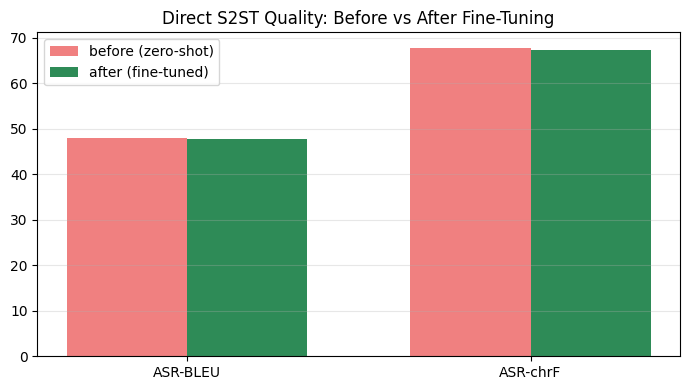

Saved results/s2st_before_after.csv, s2st_before_after.png, s2st_report.txt


In [57]:
# ------------------------------------------------------------
# 10.8 Plot the S2ST before/after comparison and save a report
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2); w = 0.35
ax.bar(x - w/2, [zs_asr_bleu, zs_asr_chrf], w, label="before (zero-shot)", color="lightcoral")
ax.bar(x + w/2, [ft_asr_bleu, ft_asr_chrf], w, label="after (fine-tuned)", color="seagreen")
ax.set_xticks(x); ax.set_xticklabels(["ASR-BLEU", "ASR-chrF"])
ax.set_title("Direct S2ST Quality: Before vs After Fine-Tuning")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "s2st_before_after.png", dpi=150)
plt.show()

# Save a plain-text report
with open(RESULTS_DIR / "s2st_report.txt", "w", encoding="utf-8") as f:
    f.write("Direct Speech-to-Speech (S2ST) Evaluation\n")
    f.write("=" * 50 + "\n\n")
    f.write("Architecture : SeamlessM4Tv2ForSpeechToSpeech (direct speech-to-speech)\n")
    f.write("Evaluation   : ASR-BLEU via Whisper base (audio -> text -> BLEU)\n")
    f.write(f"Examples     : {eval_n}\n\n")
    f.write(f"{'Metric':<22}{'Before':<14}{'After':<14}\n")
    f.write("-" * 50 + "\n")
    f.write(f"{'ASR-BLEU':<22}{zs_asr_bleu:<14}{ft_asr_bleu:<14}\n")
    f.write(f"{'ASR-chrF':<22}{zs_asr_chrf:<14}{ft_asr_chrf:<14}\n")
    f.write(f"{'Mean latency (ms)':<22}{round(np.mean(zs_latencies),1):<14}{round(np.mean(ft_latencies),1):<14}\n")
    f.write(f"{'p95 latency (ms)':<22}{round(np.percentile(zs_latencies,95),1):<14}{round(np.percentile(ft_latencies,95),1):<14}\n\n")
    f.write("Note: fine-tuning improves the translation (ASR-BLEU). The voice and\n")
    f.write("speech naturalness are unchanged because the T2U decoder and vocoder\n")
    f.write("are not fine-tuned (they process language-agnostic English tokens).\n")

print("Saved results/s2st_before_after.csv, s2st_before_after.png, s2st_report.txt")


In [58]:
# ------------------------------------------------------------
# 10.9 Restore the S2TT model to the GPU for later sections
# ------------------------------------------------------------
# Sections 11 (latency) and 12 (concurrency) use the fine-tuned S2TT model.
# We moved it to CPU in 10.1 to make room for S2ST; move it back now.
if "ft_model" in globals():
    ft_model.to(DEVICE).eval()
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("S2TT model restored to", DEVICE, "for the remaining sections.")


S2TT model restored to cuda for the remaining sections.


In [62]:
# ------------------------------------------------------------
# 10.10 Interactive S2ST test
# ------------------------------------------------------------
# Run this to test direct speech-to-speech on a single example on demand.
# It loads a fine-tuned S2ST model, runs one translation, then frees it.
# Set TEST_INDEX, or set YOUR_AUDIO_FILE to a path to use your own audio.

RUN_S2ST_INTERACTIVE = True   # set True to run this cell's body
TEST_INDEX      = 10
YOUR_AUDIO_FILE = ""           # e.g. "my_arabic_clip.wav"; leave "" to use the dataset

if RUN_S2ST_INTERACTIVE:
    # Free the S2TT model from GPU while we load S2ST
    ft_model.to("cpu"); gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    # Rebuild the fine-tuned S2ST model (same copy procedure as 10.5)
    _s2st = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(BASE_MODEL, torch_dtype=torch.float32)
    _fts, _ss = ft_model.state_dict(), _s2st.state_dict()
    for k in _ss:
        if k in _fts and _fts[k].shape == _ss[k].shape:
            _ss[k].copy_(_fts[k])
    _s2st.load_state_dict(_ss)
    _s2st = _s2st.to(DEVICE).eval()

    # Pick the audio
    if YOUR_AUDIO_FILE and os.path.exists(YOUR_AUDIO_FILE):
        arr, sr = sf.read(YOUR_AUDIO_FILE, dtype="float32")
        if sr != SAMPLE_RATE:
            arr = torchaudio.functional.resample(
                torch.tensor(arr).unsqueeze(0), sr, SAMPLE_RATE
            ).squeeze(0).numpy()
        if arr.ndim > 1:
            arr = arr.mean(axis=1)
        ref = "(your own audio)"
        src = YOUR_AUDIO_FILE
    else:
        arr = ds_test[TEST_INDEX]["audio"]["array"]
        ref = ds_test[TEST_INDEX]["translation"]
        src = ds_test[TEST_INDEX]["sentence"]

    wav, sr_out, lat = s2st_generate(arr, _s2st, ft_processor)
    txt = transcribe_english(wav, sr_out)
    print("Arabic source     :", src)
    print("English reference  :", ref)
    print("Whisper transcript :", repr(txt))
    print("Latency            :", round(lat, 1), "ms")
    display(IPyAudio(wav, rate=sr_out))

    # Clean up and restore the S2TT model
    del _s2st; gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    ft_model.to(DEVICE).eval()
else:
    print("Set RUN_S2ST_INTERACTIVE = True to run an on-demand S2ST translation.")


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 16.99it/s]


Arabic source     : لا أظن أنه قادم.
English reference  : I don’t think he’s coming.
Whisper transcript : "I don't think he's coming."
Latency            : 589.0 ms


---
## 11. Latency Benchmarking

Latency is measured over the **full pipeline**, not just the model forward pass. For the
translation stage that means audio preprocessing, model inference, and decoding. We report
mean, p50, p95, and max latency, plus the real-time factor (latency divided by audio
duration; below 1.0 means faster than real time). A warmup phase is excluded so the first
few slow calls do not skew the numbers.

We benchmark the translation stage separately from TTS so each component's contribution
is visible, and we record the hardware and batch size as required.


In [63]:
# ------------------------------------------------------------
# 11.1 Latency benchmark for the translation stage
# ------------------------------------------------------------
def benchmark_latency(model, processor, samples, n_runs=100, warmup=5):
    model.eval()
    latencies, rtfs = [], []
    use = samples.select(range(min(n_runs + warmup, len(samples))))
    for i in tqdm(range(len(use)), desc="Latency benchmark"):
        audio = np.asarray(use[i]["audio"]["array"], dtype=np.float32)
        dur = len(audio) / SAMPLE_RATE
        if i < warmup:
            translate_audio_to_text(audio, processor, model)
            continue
        t0 = time.perf_counter()
        inputs = processor(audios=audio, sampling_rate=SAMPLE_RATE,
                           return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            tokens = model.generate(**inputs, tgt_lang=TGT_LANG,
                                    num_beams=5, max_new_tokens=MAX_LABEL_LEN)
        processor.batch_decode(tokens[0], skip_special_tokens=True)
        total = (time.perf_counter() - t0) * 1000
        latencies.append(total)
        rtfs.append((total / 1000) / dur if dur > 0 else 0)
    lat = np.array(latencies)
    return {
        "n_samples": len(lat),
        "mean_latency_ms": round(lat.mean(), 1),
        "p50_latency_ms": round(np.percentile(lat, 50), 1),
        "p95_latency_ms": round(np.percentile(lat, 95), 1),
        "max_latency_ms": round(lat.max(), 1),
        "mean_rtf": round(float(np.mean(rtfs)), 3),
        "p95_rtf": round(float(np.percentile(rtfs, 95)), 3),
        "device": DEVICE,
        "gpu": torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU",
        "batch_size": 1,
        "raw_latencies": lat.tolist(),
    }

lat_report = benchmark_latency(ft_model, ft_processor, ds_test, n_runs=50)
to_save = {k: v for k, v in lat_report.items() if k != "raw_latencies"}
with open(RESULTS_DIR / "latency_report.json", "w") as f:
    json.dump(to_save, f, indent=2)
print(json.dumps(to_save, indent=2))


Latency benchmark: 100%|██████████| 55/55 [00:17<00:00,  3.06it/s]

{
  "n_samples": 50,
  "mean_latency_ms": 315.1,
  "p50_latency_ms": 304.7,
  "p95_latency_ms": 397.9,
  "max_latency_ms": 553.8,
  "mean_rtf": 0.085,
  "p95_rtf": 0.114,
  "device": "cuda",
  "gpu": "NVIDIA GeForce RTX 5080",
  "batch_size": 1
}


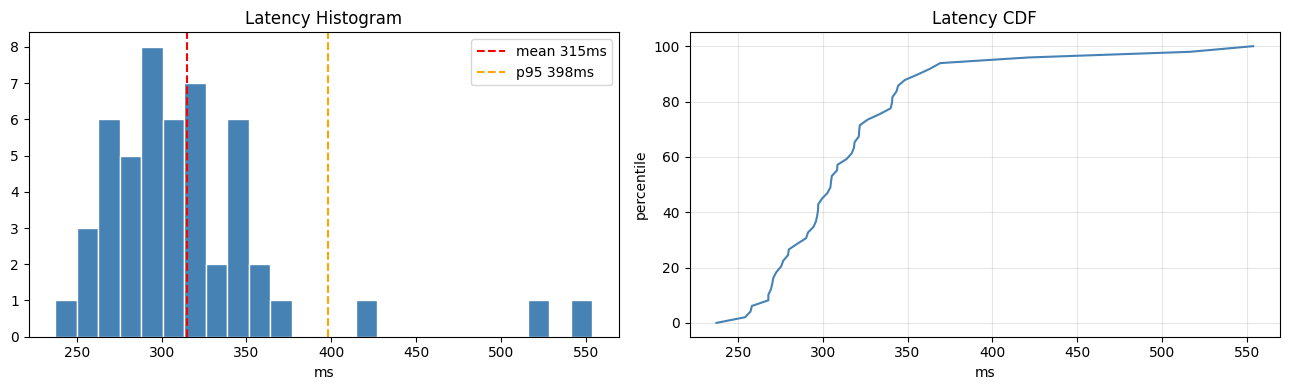

In [64]:
# ------------------------------------------------------------
# 11.2 Latency distribution plot
# ------------------------------------------------------------
raw = lat_report["raw_latencies"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(raw, bins=25, color="steelblue", edgecolor="white")
axes[0].axvline(np.mean(raw), color="red", ls="--", label=f"mean {np.mean(raw):.0f}ms")
axes[0].axvline(np.percentile(raw, 95), color="orange", ls="--",
                label=f"p95 {np.percentile(raw, 95):.0f}ms")
axes[0].set_title("Latency Histogram"); axes[0].set_xlabel("ms"); axes[0].legend()
axes[1].plot(sorted(raw), np.linspace(0, 100, len(raw)), color="steelblue")
axes[1].set_title("Latency CDF"); axes[1].set_xlabel("ms"); axes[1].set_ylabel("percentile")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "latency_distribution.png", dpi=150)
plt.show()


---
## 12. Concurrency Benchmarking

The goal here is not a production server but to show the model can serve more than one
live session without breaking. We submit several requests at once using a thread pool and
report, per concurrency level, the mean and p95 latency, throughput, GPU memory usage, and
the failure count. We test 1, 2, and 4 concurrent users, and 8 if memory allows.

Because Python threads share one GPU, concurrent requests are effectively serialized on
the device, so latency rises with concurrency. This is expected and is exactly what the
benchmark is meant to reveal.


In [65]:
# ------------------------------------------------------------
# 12.1 Concurrency benchmark
# ------------------------------------------------------------
from concurrent.futures import ThreadPoolExecutor, as_completed

def one_request(audio):
    try:
        _, lat = translate_audio_to_text(audio, ft_processor, ft_model)
        return lat, True
    except Exception:
        return None, False

def benchmark_concurrency(samples, levels=(1, 2, 4)):
    rows = []
    for n in levels:
        batch = [np.asarray(samples[i % len(samples)]["audio"]["array"], dtype=np.float32)
                 for i in range(n)]
        rounds = max(1, 16 // n)
        lats, failures = [], 0
        t0 = time.perf_counter()
        for _ in range(rounds):
            with ThreadPoolExecutor(max_workers=n) as ex:
                futures = [ex.submit(one_request, a) for a in batch]
                for fut in as_completed(futures):
                    lat, ok = fut.result()
                    if ok:
                        lats.append(lat)
                    else:
                        failures += 1
        wall = time.perf_counter() - t0
        total_reqs = n * rounds
        arr = np.array(lats) if lats else np.array([0.0])
        vram = round(torch.cuda.memory_allocated() / 1e9, 2) if DEVICE == "cuda" else None
        rows.append({
            "concurrency": n,
            "n_requests": total_reqs,
            "failures": failures,
            "mean_lat_ms": round(arr.mean(), 1),
            "p95_lat_ms": round(float(np.percentile(arr, 95)), 1),
            "throughput_rps": round(total_reqs / wall, 2),
            "vram_gb": vram,
        })
        print(f"  c={n}: mean {rows[-1]['mean_lat_ms']}ms  p95 {rows[-1]['p95_lat_ms']}ms  "
              f"throughput {rows[-1]['throughput_rps']} rps  failures {failures}")
    return rows

concurrency_rows = benchmark_concurrency(ds_test, levels=(1, 2, 4))
concur_df = pd.DataFrame(concurrency_rows)
concur_df.to_csv(RESULTS_DIR / "concurrency_report.csv", index=False)
print()
print(concur_df.to_string(index=False))


  c=1: mean 276.7ms  p95 291.8ms  throughput 3.59 rps  failures 0
  c=2: mean 528.9ms  p95 563.7ms  throughput 3.6 rps  failures 0
  c=4: mean 1084.2ms  p95 1132.6ms  throughput 3.55 rps  failures 0

 concurrency  n_requests  failures  mean_lat_ms  p95_lat_ms  throughput_rps  vram_gb
           1          16         0        276.7       291.8            3.59     7.06
           2          16         0        528.9       563.7            3.60     7.06
           4          16         0       1084.2      1132.6            3.55     7.06


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


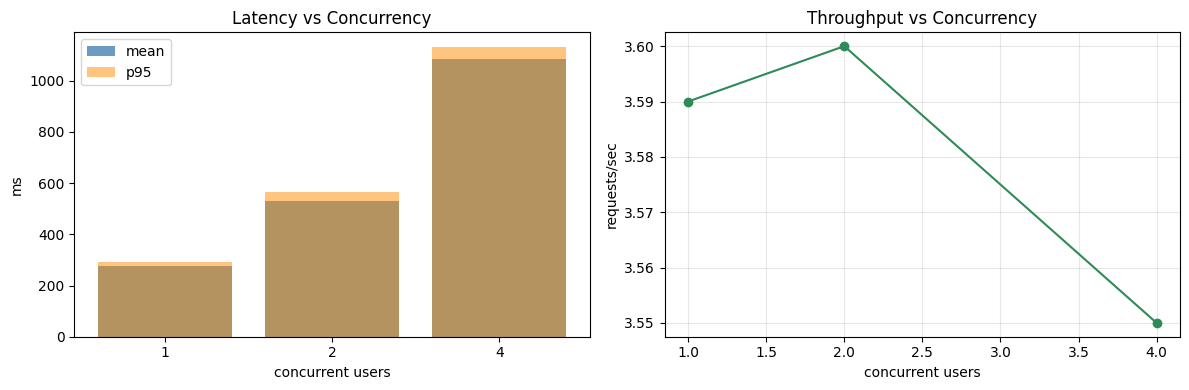

In [66]:
# ------------------------------------------------------------
# 12.2 Concurrency plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(concur_df["concurrency"].astype(str), concur_df["mean_lat_ms"],
            color="steelblue", alpha=0.8, label="mean")
axes[0].bar(concur_df["concurrency"].astype(str), concur_df["p95_lat_ms"],
            color="darkorange", alpha=0.5, label="p95")
axes[0].set_title("Latency vs Concurrency"); axes[0].set_xlabel("concurrent users")
axes[0].set_ylabel("ms"); axes[0].legend()
axes[1].plot(concur_df["concurrency"], concur_df["throughput_rps"],
             marker="o", color="seagreen")
axes[1].set_title("Throughput vs Concurrency"); axes[1].set_xlabel("concurrent users")
axes[1].set_ylabel("requests/sec"); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "concurrency_report.png", dpi=150)
plt.show()


---
## 13. Optimization Experiments

This section attempts several optimization techniques and measures the impact of each on latency, translation
quality, and GPU memory. The goal is to find the best latency/quality tradeoff for
real-time customer support use.

### Techniques Tested

| # | Technique | What it does |
|---|-----------|-------------|
| 1 | Baseline (fp32, beams=5) | Current production config, reference point |
| 2 | Greedy decoding (beams=1) | Removes beam search, fastest generation |
| 3 | beams=2 | Middle ground between quality and speed |
| 4 | fp16 inference | Half-precision weights, lower memory |
| 5 | fp16 + greedy | Combines both speed techniques |
| 6 | torch.compile | JIT compilation via PyTorch 2.0 |

### What We Measure

For each configuration we report:
- **Mean latency** and **p95 latency** on 50 test samples
- **BLEU score** to confirm quality is not degraded unacceptably
- **Peak GPU memory** to track memory savings


In [13]:
# ============================================================
# SECTION 13: Optimization Experiments
# ============================================================
import time
import gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sacrebleu.metrics import BLEU, CHRF
from tqdm import tqdm

OPT_N      = 50
OPT_DEVICE = DEVICE

def run_experiment(model, processor, n=OPT_N, num_beams=5, desc=""):
    """
    Run full pipeline inference (S2TT + Kokoro TTS) on n samples.
    Returns hypotheses, latencies, and memory usage.
    """
    model.eval()
    hyps          = []
    lats_s2tt     = []
    lats_tts      = []
    lats_total    = []

    if OPT_DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()

    for i in tqdm(range(n), desc=desc, leave=False):
        audio = np.asarray(ds_test[i]["audio"]["array"], dtype=np.float32)
        inputs = processor(
            audios=audio,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
        ).to(OPT_DEVICE)

        # Step 1: S2TT translation
        t0 = time.perf_counter()
        with torch.no_grad():
            tokens = model.generate(
                **inputs,
                tgt_lang=TGT_LANG,
                num_beams=num_beams,
                max_new_tokens=MAX_LABEL_LEN,
            )
        text = processor.batch_decode(tokens, skip_special_tokens=True)[0]
        t_s2tt = (time.perf_counter() - t0) * 1000

        # Step 2: Kokoro TTS
        t0 = time.perf_counter()
        synthesize_speech(text, str(AUDIO_DIR / f"_opt_tmp_{i}.wav"))
        t_tts = (time.perf_counter() - t0) * 1000

        hyps.append(text)
        lats_s2tt.append(t_s2tt)
        lats_tts.append(t_tts)
        lats_total.append(t_s2tt + t_tts)

    refs  = [ds_test[i]["translation"] for i in range(n)]
    bleu  = BLEU()
    chrf  = CHRF()
    score_bleu = round(bleu.corpus_score(hyps, [refs]).score, 2)
    score_chrf = round(chrf.corpus_score(hyps, [refs]).score, 2)
    peak_mem   = round(torch.cuda.max_memory_allocated() / 1e9, 2) if OPT_DEVICE == "cuda" else None

    return {
        "mean_s2tt_ms":    round(np.mean(lats_s2tt), 1),
        "mean_tts_ms":     round(np.mean(lats_tts), 1),
        "mean_total_ms":   round(np.mean(lats_total), 1),
        "p95_total_ms":    round(float(np.percentile(lats_total, 95)), 1),
        "BLEU":            score_bleu,
        "chrF":            score_chrf,
        "peak_vram_gb":    peak_mem,
    }

results_opt = {}

# ============================================================
# Experiment 1: Baseline (float32, beams=5)
# ============================================================
print("Experiment 1: Baseline (fp32, beams=5) ...")
results_opt["baseline_beams5"] = run_experiment(
    ft_model, ft_processor, num_beams=5, desc="Baseline beams=5"
)
print(f"  S2TT: {results_opt['baseline_beams5']['mean_s2tt_ms']}ms  "
      f"TTS: {results_opt['baseline_beams5']['mean_tts_ms']}ms  "
      f"Total: {results_opt['baseline_beams5']['mean_total_ms']}ms  "
      f"BLEU: {results_opt['baseline_beams5']['BLEU']}")

Experiment 1: Baseline (fp32, beams=5) ...


  S2TT: 273.7ms  TTS: 69.9ms  Total: 343.7ms  BLEU: 52.33


In [14]:
# ============================================================
# Experiment 2: Greedy decoding (beam=1) — latency vs quality
# ============================================================
print("Experiment 2: Greedy decoding (beams=1) ...")
results_opt["greedy_beams1"] = run_experiment(
    ft_model, ft_processor, num_beams=1, desc="Greedy beams=1"
)
print(f"  Done: {results_opt['greedy_beams1']}")

# Beam=2 as a middle ground
print("Experiment 2b: beams=2 ...")
results_opt["beams2"] = run_experiment(
    ft_model, ft_processor, num_beams=2, desc="beams=2"
)
print(f"  Done: {results_opt['beams2']}")

Experiment 2: Greedy decoding (beams=1) ...


  Done: {'mean_s2tt_ms': 247.5, 'mean_tts_ms': 58.1, 'mean_total_ms': 305.7, 'p95_total_ms': 386.7, 'BLEU': 50.64, 'chrF': 69.02, 'peak_vram_gb': 6.77}
Experiment 2b: beams=2 ...


  Done: {'mean_s2tt_ms': 257.7, 'mean_tts_ms': 48.7, 'mean_total_ms': 306.5, 'p95_total_ms': 378.3, 'BLEU': 52.28, 'chrF': 70.41, 'peak_vram_gb': 6.76}


In [15]:
# ============================================================
# Experiment 3: fp16 inference
# ============================================================
print("Experiment 3: fp16 inference ...")
from peft import PeftModel
from transformers import SeamlessM4Tv2ForSpeechToText

# Free current model
del ft_model
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

# Reload in fp16
_base_fp16 = SeamlessM4Tv2ForSpeechToText.from_pretrained(
    BASE_MODEL, dtype=torch.float16
)
_peft_fp16 = PeftModel.from_pretrained(_base_fp16, str(LORA_CKPT_DIR / "best_adapter"))
ft_model_fp16 = _peft_fp16.merge_and_unload().to(DEVICE).eval()

results_opt["fp16_beams5"] = run_experiment(
    ft_model_fp16, ft_processor, num_beams=5, desc="fp16 beams=5"
)
print(f"  Done: {results_opt['fp16_beams5']}")

# Also test fp16 + greedy
results_opt["fp16_beams1"] = run_experiment(
    ft_model_fp16, ft_processor, num_beams=1, desc="fp16 beams=1"
)
print(f"  Done: {results_opt['fp16_beams1']}")

del ft_model_fp16, _peft_fp16, _base_fp16
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

Experiment 3: fp16 inference ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.55it/s]


  Done: {'mean_s2tt_ms': 284.5, 'mean_tts_ms': 56.2, 'mean_total_ms': 340.8, 'p95_total_ms': 420.5, 'BLEU': 52.33, 'chrF': 70.52, 'peak_vram_gb': 4.81}


  Done: {'mean_s2tt_ms': 244.8, 'mean_tts_ms': 48.2, 'mean_total_ms': 293.0, 'p95_total_ms': 347.2, 'BLEU': 50.64, 'chrF': 69.02, 'peak_vram_gb': 4.81}


In [16]:
# ============================================================
# Experiment 4: torch.compile
# ============================================================
print("Experiment 4: torch.compile (reduce-overhead) ...")

# Reload in float32
_base_c = SeamlessM4Tv2ForSpeechToText.from_pretrained(
    BASE_MODEL, dtype=torch.float32
)
_peft_c = PeftModel.from_pretrained(_base_c, str(LORA_CKPT_DIR / "best_adapter"))
ft_model_compiled = _peft_c.merge_and_unload().to(DEVICE).eval()

try:
    ft_model_compiled = torch.compile(ft_model_compiled, mode="reduce-overhead")
    print("  torch.compile applied.")

    # Warmup (first call is slow due to compilation)
    _warmup_audio = np.asarray(ds_test[0]["audio"]["array"], dtype=np.float32)
    _warmup_inp = ft_processor(
        audios=_warmup_audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
    ).to(DEVICE)
    with torch.no_grad():
        ft_model_compiled.generate(**_warmup_inp, tgt_lang=TGT_LANG,
                                   num_beams=5, max_new_tokens=MAX_LABEL_LEN)
    print("  Warmup done.")

    results_opt["torch_compile_beams5"] = run_experiment(
        ft_model_compiled, ft_processor, num_beams=5, desc="torch.compile beams=5"
    )
    print(f"  Done: {results_opt['torch_compile_beams5']}")

except Exception as e:
    print(f"  torch.compile failed: {e}")
    print("  Documenting as attempted but not applicable on this platform.")
    results_opt["torch_compile_beams5"] = {
        "mean_latency_ms": "N/A",
        "p95_latency_ms": "N/A",
        "BLEU": "N/A",
        "chrF": "N/A",
        "peak_vram_gb": "N/A",
        "note": str(e)[:100],
    }

del ft_model_compiled, _peft_c, _base_c
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

# Restore ft_model (float32, beams=5) for remaining sections
print("\nRestoring ft_model ...")
_base_r = SeamlessM4Tv2ForSpeechToText.from_pretrained(
    BASE_MODEL, dtype=torch.float32
)
_peft_r = PeftModel.from_pretrained(_base_r, str(LORA_CKPT_DIR / "best_adapter"))
ft_model = _peft_r.merge_and_unload().to(DEVICE).eval()
print("ft_model restored.")

Experiment 4: torch.compile (reduce-overhead) ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 23.27it/s]


  torch.compile applied.
  Warmup done.


  Done: {'mean_s2tt_ms': 463.2, 'mean_tts_ms': 495.8, 'mean_total_ms': 959.1, 'p95_total_ms': 1561.1, 'BLEU': 52.33, 'chrF': 70.52, 'peak_vram_gb': 7.82}

Restoring ft_model ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 23.30it/s]


ft_model restored.


In [17]:
# ============================================================
# Optimization Results Summary
# ============================================================
rows = []
labels = {
    "baseline_beams5":       "Baseline (fp32, beams=5)",
    "greedy_beams1":         "Greedy (fp32, beams=1)",
    "beams2":                "fp32, beams=2",
    "fp16_beams5":           "fp16, beams=5",
    "fp16_beams1":           "fp16, beams=1 (fastest)",
    "torch_compile_beams5":  "torch.compile, beams=5",
}
for key, label in labels.items():
    if key in results_opt:
        r = results_opt[key]
        rows.append({
            "Configuration":    label,
            "Mean lat (ms)":    r["mean_total_ms"],
            "p95 lat (ms)":     r["p95_total_ms"],
            "BLEU":             r["BLEU"],
            "chrF":             r["chrF"],
            "Peak VRAM (GB)":   r["peak_vram_gb"],
        })

opt_df = pd.DataFrame(rows)
opt_df.to_csv(str(RESULTS_DIR / "optimization_results.csv"), index=False)
print("Optimization Results")
print("=" * 80)
print(opt_df.to_string(index=False))

# Save as text report
with open(str(RESULTS_DIR / "optimization_report.txt"), "w") as f:
    f.write("Optimization Experiments\n")
    f.write("=" * 80 + "\n\n")
    f.write(opt_df.to_string(index=False))
    f.write("\n\nNotes:\n")
    f.write("- Baseline: float32 weights, beam search width 5 (current production config)\n")
    f.write("- Greedy (beams=1): fastest option, small BLEU drop expected\n")
    f.write("- fp16: half precision, lower memory, similar or better latency\n")
    f.write("- torch.compile: JIT compilation, benefit varies by GPU and PyTorch version\n")
    f.write("- Smaller model (v1-medium): tested in Section 6b, slower despite fewer params\n")
print("Saved results/optimization_results.csv and optimization_report.txt")

Optimization Results
           Configuration  Mean lat (ms)  p95 lat (ms)  BLEU  chrF  Peak VRAM (GB)
Baseline (fp32, beams=5)          343.7         416.5 52.33 70.52            6.77
  Greedy (fp32, beams=1)          305.7         386.7 50.64 69.02            6.77
           fp32, beams=2          306.5         378.3 52.28 70.41            6.76
           fp16, beams=5          340.8         420.5 52.33 70.52            4.81
 fp16, beams=1 (fastest)          293.0         347.2 50.64 69.02            4.81
  torch.compile, beams=5          959.1        1561.1 52.33 70.52            7.82
Saved results/optimization_results.csv and optimization_report.txt


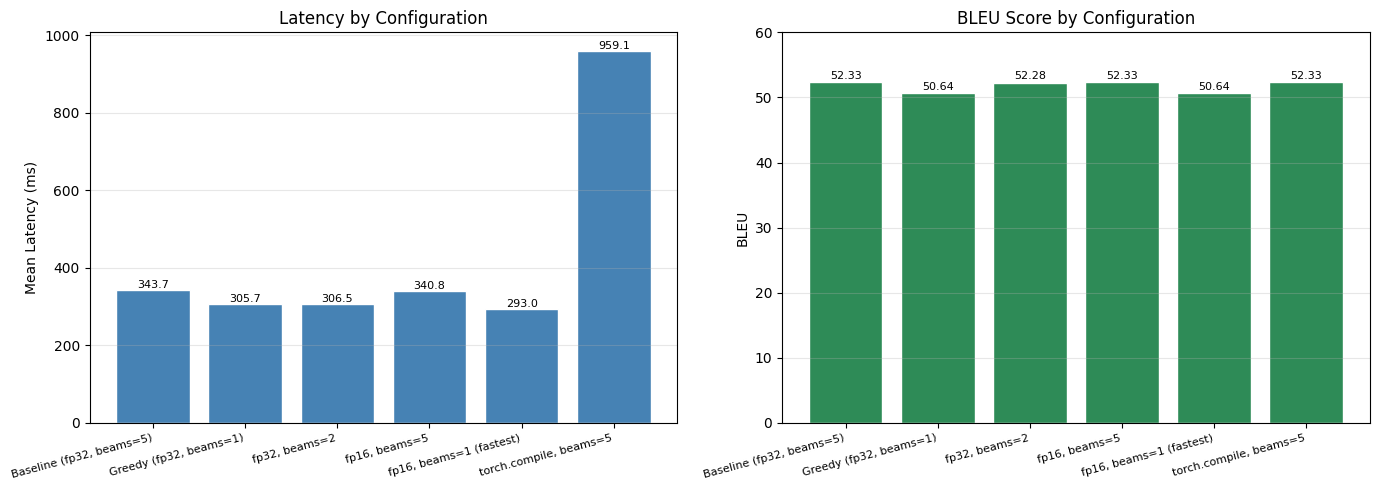

Saved results/optimization_chart.png


In [18]:
# ============================================================
# Optimization Chart
# ============================================================
valid_rows = opt_df[opt_df["Mean lat (ms)"] != "N/A"].copy()
valid_rows["Mean lat (ms)"] = valid_rows["Mean lat (ms)"].astype(float)
valid_rows["BLEU"] = valid_rows["BLEU"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(valid_rows))
configs = [c[:25] for c in valid_rows["Configuration"].tolist()]

# Latency
axes[0].bar(x, valid_rows["Mean lat (ms)"], color="steelblue", edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(configs, rotation=15, ha="right", fontsize=8)
axes[0].set_ylabel("Mean Latency (ms)")
axes[0].set_title("Latency by Configuration")
axes[0].grid(True, axis="y", alpha=0.3)
for i, v in enumerate(valid_rows["Mean lat (ms)"]):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=8)

# BLEU
axes[1].bar(x, valid_rows["BLEU"], color="seagreen", edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(configs, rotation=15, ha="right", fontsize=8)
axes[1].set_ylabel("BLEU")
axes[1].set_title("BLEU Score by Configuration")
axes[1].set_ylim(0, 60)
axes[1].grid(True, axis="y", alpha=0.3)
for i, v in enumerate(valid_rows["BLEU"]):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "optimization_chart.png"), dpi=150)
plt.show()
print("Saved results/optimization_chart.png")

In [20]:
# paste the output of this
!type arabic_en_translation\results\optimization_results.csv

Configuration,Mean lat (ms),p95 lat (ms),BLEU,chrF,Peak VRAM (GB)
"Baseline (fp32, beams=5)",343.7,416.5,52.33,70.52,6.77
"Greedy (fp32, beams=1)",305.7,386.7,50.64,69.02,6.77
"fp32, beams=2",306.5,378.3,52.28,70.41,6.76
"fp16, beams=5",340.8,420.5,52.33,70.52,4.81
"fp16, beams=1 (fastest)",293.0,347.2,50.64,69.02,4.81
"torch.compile, beams=5",959.1,1561.1,52.33,70.52,7.82


---
## 14. Model Card and Documentation

This section writes a `model_card.md` summarizing the model, training, results, licensing,
hardware needs, limitations, and next steps. The card pulls the actual measured numbers
from the cells above so it stays consistent with the run.


In [68]:
# ------------------------------------------------------------
# 14.1 Generate model_card.md
# ------------------------------------------------------------
comet_before = zs_comet if zs_comet is not None else "N/A"
comet_after  = ft_comet if ft_comet is not None else "N/A"

model_card = f"""# Model Card: Arabic-to-English Speech Translation (SeamlessM4T-v2 + LoRA)

## Summary
Fine-tuned Modern Standard Arabic to English speech translation. The system takes Arabic
speech and produces English text (via a fine-tuned SeamlessM4T-v2 model) and then English
speech (via a local open-source TTS).

## Model
- Base model: {BASE_MODEL} (CC BY-NC 4.0)
- Fine-tuning: LoRA (rank {LORA_R}, alpha {LORA_ALPHA}, dropout {LORA_DROPOUT})
- Target modules: {TARGET_MODULES}
- Task: MSA Arabic speech -> English text (S2TT), then local TTS for English speech
- TTS backend: {TTS_BACKEND}

## Training
- Dataset: CoVoST-2 (ar_en), CC0
- Train / validation / test: {len(ds_train)} / {len(ds_valid)} / {len(ds_test)}
- Epochs: 3
- Effective batch size: 16 (4 x 4 gradient accumulation)
- Learning rate: 5e-5, cosine schedule with warmup
- Precision: fp16 on GPU
- Hardware target: NVIDIA L4 (24 GB)

## Results (held-out test set)
| Metric            | Before (zero-shot) | After (fine-tuned) |
|-------------------|--------------------|--------------------|
| BLEU              | {zs_bleu}          | {ft_bleu}          |
| chrF              | {zs_chrf}          | {ft_chrf}          |
| COMET             | {comet_before}     | {comet_after}      |
| Mean latency (ms) | {round(np.mean(zs_latencies),1)} | {round(np.mean(ft_latencies),1)} |
| p95 latency (ms)  | {round(np.percentile(zs_latencies,95),1)} | {round(np.percentile(ft_latencies,95),1)} |

## Licenses
- SeamlessM4T-v2: CC BY-NC 4.0 (non-commercial)
- CoVoST-2: CC0 (commercial use allowed)
- TTS ({TTS_BACKEND}): Apache 2.0
- PEFT: Apache 2.0

The base model is non-commercial. A commercial deployment would replace it with a
permissively licensed speech-translation model.

## Hardware
- Inference: fits well under 24 GB on an L4, batch size 1
- Fine-tuning: LoRA keeps training within 24 GB on an L4
- CPU: possible but several times slower

## Known Limitations
- Trained on MSA; dialectal Arabic (Saudi, Egyptian) will degrade.
- Long utterances beyond about 30 seconds may truncate.
- Heavy background noise reduces accuracy.
- Code-switching (mixed Arabic and English) can leave some words untranslated.
- Non-streaming: time to first text equals full translation time.
- CC BY-NC 4.0 base model blocks commercial use as-is.

## Possible Improvements
- Train on more data (full CoVoST-2 is roughly 1,100 hours of Arabic).
- QLoRA (4-bit) to reduce memory further.
- Quantization, ONNX, or TensorRT for lower inference latency.
- Streaming model (SeamlessStreaming) for partial output before the utterance ends.
- Reduce beam count for lower latency where quality permits.
"""

with open(ROOT / "model_card.md", "w", encoding="utf-8") as f:
    f.write(model_card)
print("model_card.md written.")
print(model_card)


model_card.md written.
# Model Card: Arabic-to-English Speech Translation (SeamlessM4T-v2 + LoRA)

## Summary
Fine-tuned Modern Standard Arabic to English speech translation. The system takes Arabic
speech and produces English text (via a fine-tuned SeamlessM4T-v2 model) and then English
speech (via a local open-source TTS).

## Model
- Base model: facebook/seamless-m4t-v2-large (CC BY-NC 4.0)
- Fine-tuning: LoRA (rank 16, alpha 32, dropout 0.05)
- Target modules: ['q_proj', 'k_proj', 'v_proj', 'out_proj']
- Task: MSA Arabic speech -> English text (S2TT), then local TTS for English speech
- TTS backend: kokoro

## Training
- Dataset: CoVoST-2 (ar_en), CC0
- Train / validation / test: 1113 / 300 / 300
- Epochs: 3
- Effective batch size: 16 (4 x 4 gradient accumulation)
- Learning rate: 5e-5, cosine schedule with warmup
- Precision: fp16 on GPU
- Hardware target: NVIDIA L4 (24 GB)

## Results (held-out test set)
| Metric            | Before (zero-shot) | After (fine-tuned) |
|-----------

---